<div style="display: flex; align-items: center; justify-content: center; flex-wrap: wrap;">
    <div style="flex: 1; max-width: 400px; display: flex; justify-content: center;">
        <img src="https://magic.novaims.unl.pt/media/1tdf2arr/ims25_horizontal__positivo_rgb.svg" style="max-width: 70%; height: auto; margin-top: 50px; margin-bottom: 50px; margin-left: 6rem;">
    </div>
    <div style="flex: 2; text-align: center; margin-top: 20px; margin-left: 6rem;">
        <div style="font-size: 28px; font-weight: bold; line-height: 1.2;">
            <span style="color: #FFCD41;">Thesis Project |</span> <span style="color: #F58228;">LISBOA Evaluation Results Analysis</span>
        </div>
        <div style="font-size: 17px; font-weight: bold; margin-top: 10px;">2025 - 2026</div>
        <div style="font-size: 17px; font-weight: bold;">Master in Data Science and Advanced Analytics</div>
        <div style="margin-top: 20px;"><div>André Filipe Gomes Silvestre, 20240502</div></div>
    </div>
</div>

<style>
@import url('https://fonts.cdnfonts.com/css/avenir-next-lt-pro?styles=29974');
</style>

<div style="background: linear-gradient(to right, #F58228, #FFCD41); padding: 15px; color: white; border-radius: 300px; text-align: center;">
    <center><h1 style="margin-left: 100px; margin-top: 10px; margin-bottom: 4px; color: white; font-size: 32px; font-family: 'Avenir Next LT Pro', sans-serif;"><b>Benchmark and Ablation Analysis</b></h1></center>
</div>

<br><br>

## **Notebook overview**

This notebook analyses the persisted evaluation artefacts under `eval/results/` and turns them into thesis-ready tables and figures. As of 2026-04, the shared evaluation corpus contains 72 entries across 6 domains, while each saved benchmark or ablation artefact can use a narrower subset depending on the runner and its filters.

### **What this notebook does**

1. Maps the full shared evaluation corpus and the smaller subsets actually used by each artefact.
2. Compares isolated worker-agent benchmark results across the response models stored in the JSON outputs.
3. Reframes the ablation around quality lift, operational trade-offs, and grounded-system evidence.
4. Summarises strict live coverage, provider consistency, and optional calibration without overloading the main narrative.
5. Reads the stored metadata dynamically so dataset-path overrides and custom `output-prefix` runs remain analysable without rewriting the notebook.

## **Evaluation scope and reading guide**

This repository uses several complementary evaluation layers, and each one answers a different methodological question:

- **Shared corpus**: the full `evaluation_groundtruth_queries.json` file defines the overall evaluation scope, domain balance, expected tools, and expected facts.
- **Benchmark**: evaluates isolated worker agents, not the full LISBOA orchestration pipeline.
- **Ablation**: compares a zero-shot baseline against the full LISBOA system on the same persisted query subset.
- **Coverage**: checks whether the strict live prompt manifest exercises the exported tool registry.
- **Provider consistency**: checks whether different providers preserve the same response contract and presentation style.
- **Calibration**: optionally compares human scores with judge scores when a calibration artefact is available.

### **Interpretation notes**

- Counts shown for the full corpus are not the same as the counts used in each saved artefact.
- The default ablation runner focuses on the grounded pipeline domains and excludes `greeting` plus `out_of_scope`, because those are direct SupervisorAgent shortcuts rather than grounded worker-agent flows.
- Benchmark plots treat **tool F1** as a grounded quality signal for isolated worker agents.
- Ablation plots do **not** treat zero-shot and LISBOA as symmetric on tool use, because zero-shot has no tool grounding by design.
- When the sample size is small, this notebook prefers annotated grouped bars, compact tables, and trade-off plots over boxplots.

In [1]:
# ==========================================================================
# Core setup
# ==========================================================================
# pip install pandas numpy matplotlib seaborn

import json
import re
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib import font_manager
from matplotlib.axes import Axes
from matplotlib.figure import Figure

%matplotlib inline


def resolve_project_root() -> Path:
    """Resolve the repository root even when the notebook is opened from eval/."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "config.py").exists() and (candidate / "eval" / "results").exists():
            return candidate
    return Path.cwd()


def pick_plot_font() -> str:
    """Pick the closest available font to the thesis notebook style."""
    preferred_fonts = ["Avenir Next LT Pro", "Avenir Next", "Arial", "DejaVu Sans"]
    available_fonts = {font.name for font in font_manager.fontManager.ttflist}
    for font_name in preferred_fonts:
        if font_name in available_fonts:
            return font_name
    return "DejaVu Sans"


PROJECT_ROOT = resolve_project_root()
EVAL_DIR = PROJECT_ROOT / "eval"
EVAL_RESULTS_DIR = EVAL_DIR / "results"
CORPUS_PATH = EVAL_DIR / "evaluation_groundtruth_queries.json"
DEMO_CORPUS_PATH = EVAL_DIR / "evaluation_groundtruth_queries_demo.json"
FIGURES_DIR = EVAL_RESULTS_DIR / "figures"
EXPORT_DPI = 300
EXPORT_MAIN_FIGURES = True
EXPORT_FLAT_TABLES = False
MAIN_FIGURE_EXPORTS = {
    "benchmark_quality_grounding",
    "benchmark_operational_profile",
    "ablation_quality_lift",
    "ablation_tradeoffs",
}
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PLOT_FONT = pick_plot_font()

PRIMARY_RED = "#d9482a"
SECONDARY_ORANGE = "#f2a65a"
ACCENT_YELLOW = "#f6da00"
NEUTRAL_GREY = "#8b96a3"
LIGHT_GREY = "#d9dfe6"
DARK_GREY = "#2f2f2f"
SOFT_BLUE = "#6b93c6"
SOFT_GREEN = "#6fa36b"
SOFT_SILVER = "#c9d2dd"

PROJECT_PALETTE = [PRIMARY_RED, SECONDARY_ORANGE, SOFT_BLUE, SOFT_GREEN, ACCENT_YELLOW]

sns.set_theme(context="notebook", style="whitegrid", font=PLOT_FONT, font_scale=1.0)
sns.set_palette(PROJECT_PALETTE)
plt.rcParams["figure.figsize"] = (15, 7)
plt.rcParams["figure.dpi"] = EXPORT_DPI
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11.5
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.labelsize"] = 10.0
plt.rcParams["ytick.labelsize"] = 10.0
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["legend.title_fontsize"] = 10
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = [PLOT_FONT, "Arial", "DejaVu Sans"]
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["axes.edgecolor"] = DARK_GREY
plt.rcParams["text.color"] = DARK_GREY
plt.rcParams["axes.labelcolor"] = DARK_GREY
plt.rcParams["xtick.color"] = DARK_GREY
plt.rcParams["ytick.color"] = DARK_GREY
plt.rcParams["grid.color"] = LIGHT_GREY
plt.rcParams["grid.alpha"] = 0.55
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print(f"Project root: {PROJECT_ROOT}")
print(f"Corpus path: {CORPUS_PATH.relative_to(PROJECT_ROOT)}")
print(f"Demo corpus path: {DEMO_CORPUS_PATH.relative_to(PROJECT_ROOT)}")
print(f"Figures directory: {FIGURES_DIR.relative_to(PROJECT_ROOT)}")
print(f"Automatic figure export: {EXPORT_MAIN_FIGURES}")
print(f"Automatic flat-table export: {EXPORT_FLAT_TABLES}")
print(f"Plot font: {PLOT_FONT}")

Project root: c:\Users\andre\OneDrive - NOVAIMS\[MDSAA-DS]_Thesis\Thesis2025-26_AFGS
Corpus path: eval\evaluation_groundtruth_queries.json
Demo corpus path: eval\evaluation_groundtruth_queries_demo.json
Figures directory: eval\results\figures
Automatic figure export: True
Automatic flat-table export: False
Plot font: Avenir Next LT Pro


In [2]:
# ==========================================================================
# Formatting and plotting helpers
# ==========================================================================
DOMAIN_LABELS = {
    "weather": "Weather",
    "transport": "Transport",
    "researcher": "Researcher",
    "multi_agent": "Multi-agent",
    "greeting": "Greeting",
    "out_of_scope": "Out of scope",
}
BENCHMARK_DOMAIN_ORDER = ["Weather", "Transport", "Researcher"]
ABLATION_DOMAIN_ORDER = ["Greeting", "Weather", "Transport", "Researcher", "Multi-agent", "Out of scope"]
ARM_LABELS = {"zero_shot": "Zero-shot", "lisboa": "LISBOA"}
ARM_PALETTE = {"Zero-shot": SOFT_SILVER, "LISBOA": PRIMARY_RED}


def format_model_label(model_name: str | None) -> str:
    """Format model labels for notebook display without provider prefixes."""
    if model_name is None:
        return "N/A"

    label = str(model_name).strip()
    special_labels = {
        "Multi-Agent (gpt-5-mini)": "LISBOA Multi-Agent",
        "multi_agent": "LISBOA Multi-Agent",
        "zero_shot": "Zero-shot",
        "lisboa": "LISBOA",
    }
    if label in special_labels:
        return special_labels[label]

    if "::" in label:
        label = label.split("::", 1)[1]

    if label.lower().startswith("multi-agent"):
        inner = re.search(r"\((.+)\)", label)
        if inner:
            return f"LISBOA Multi-Agent ({format_model_label(inner.group(1))})"
        return "LISBOA Multi-Agent"

    if label.lower() == "qwen/qwen3.5-9b":
        return "Qwen 3.5 9B"

    if label.lower().startswith("kimi-k2.5"):
        suffix = label[len("kimi-k2.5"):].strip(" -_")
        return "Kimi K2.5" if not suffix else f"Kimi K2.5 {suffix.replace('-', ' ').title()}"

    gpt_match = re.fullmatch(r"gpt-(\d+(?:\.\d+)?)(?:-(.+))?", label.lower())
    if gpt_match:
        version, variant = gpt_match.groups()
        if variant:
            formatted_variant = " ".join(
                part.upper() if len(part) <= 2 else part.capitalize()
                for part in variant.split("-")
            )
            return f"GPT-{version} {formatted_variant}"
        return f"GPT-{version}"

    return label.replace("_", " ").replace("-", " ").title()


def format_domain_label(domain_name: str | None) -> str:
    """Format evaluation domains for notebook display."""
    if domain_name is None:
        return "Unknown"
    return DOMAIN_LABELS.get(str(domain_name), str(domain_name).replace("_", " ").title())


def format_arm_label(arm_name: str | None) -> str:
    """Format ablation arm names for notebook display."""
    if arm_name is None:
        return "Unknown"
    return ARM_LABELS.get(str(arm_name), str(arm_name).replace("_", " ").title())


def format_response_models_for_inventory(value: Any) -> str:
    """Format response model inventories for display without provider prefixes."""
    if isinstance(value, dict):
        return " | ".join(
            f"{format_arm_label(key)}: {format_model_label(model)}"
            for key, model in value.items()
        )
    if isinstance(value, (list, tuple, set)):
        return ", ".join(format_model_label(model) for model in value)
    if value is None:
        return "N/A"
    return format_model_label(str(value))


def build_palette(labels: list[str]) -> dict[str, str]:
    """Map labels to the project palette in a stable order."""
    return {
        label: PROJECT_PALETTE[index % len(PROJECT_PALETTE)]
        for index, label in enumerate(labels)
    }


def save_figure(name: str, fig: Figure | None = None) -> Path | None:
    """Export only the selected thesis-ready SVG figures."""
    if not EXPORT_MAIN_FIGURES or name not in MAIN_FIGURE_EXPORTS:
        return None

    fig = fig or plt.gcf()
    fig.patch.set_facecolor("white")
    for ax in fig.axes:
        ax.set_facecolor("white")

    for ext in ("png", "pdf"):
        legacy_path = FIGURES_DIR / f"{name}.{ext}"
        if legacy_path.exists():
            legacy_path.unlink()

    svg_path = FIGURES_DIR / f"{name}.svg"
    fig.savefig(svg_path, format="svg", bbox_inches="tight", facecolor="white")
    print(f"Exported: {svg_path.relative_to(PROJECT_ROOT)}")
    return svg_path


def style_axis(
    ax: Axes,
    title: str,
    xlabel: str,
    ylabel: str,
    *,
    rotate_xticks: int = 0,
    y_limits: tuple[float, float] | None = None,
    show_y_grid: bool = True,
) -> None:
    """Apply a thesis-ready style to an axis."""
    ax.set_facecolor("white")
    ax.set_title(title, fontsize=15, fontweight="bold", pad=14)
    ax.set_xlabel(xlabel, fontsize=11.5, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=11.5, fontweight="bold")
    if y_limits is not None:
        ax.set_ylim(*y_limits)
    ax.tick_params(axis="x", rotation=rotate_xticks)
    if show_y_grid:
        ax.grid(True, axis="y", linestyle="--", alpha=0.55, color=LIGHT_GREY)
    else:
        ax.grid(False, axis="y")
    sns.despine(ax=ax, left=True, bottom=False)


def style_legend(ax: Axes, title: str, bbox_to_anchor: tuple[float, float] = (1.02, 1.0)) -> None:
    """Move and style a legend consistently across plots."""
    if ax.legend_ is None:
        return
    sns.move_legend(ax, "upper left", bbox_to_anchor=bbox_to_anchor, title=title, frameon=True)
    if ax.legend_ is None:
        return
    ax.legend_.get_title().set_fontweight("bold")
    ax.legend_.get_frame().set_edgecolor("#d0d0d0")
    ax.legend_.get_frame().set_linewidth(0.8)
    ax.legend_.get_frame().set_alpha(0.98)


def format_demo_runner(domain_name: str) -> str:
    """Return the most appropriate runner for a demo query domain."""
    if domain_name in {"weather", "transport", "researcher"}:
        return "Benchmark and ablation"
    return "Ablation only"

In [3]:
# ==========================================================================
# Visual overrides and chart helpers
# ==========================================================================
from matplotlib.patches import FancyBboxPatch

preferred_notebook_fonts = ["Borna", "Arial", "DejaVu Sans"]
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for candidate_font in preferred_notebook_fonts:
    if candidate_font in available_fonts:
        PLOT_FONT = candidate_font
        break

PRIMARY_RED = "#ff4011"
SECONDARY_ORANGE = "#F58228"
ACCENT_YELLOW = "#f6da00"
NEUTRAL_GREY = "#8b96a3"
LIGHT_GREY = "#e6e9ee"
DARK_GREY = "#222222"
SOFT_BLUE = "#5f85a2"
SOFT_GREEN = "#7aa874"
SOFT_SILVER = "#d7dce2"

PROJECT_PALETTE = [PRIMARY_RED, SECONDARY_ORANGE, ACCENT_YELLOW, NEUTRAL_GREY, SOFT_BLUE]
ARM_PALETTE = {"Zero-shot": NEUTRAL_GREY, "LISBOA": ACCENT_YELLOW}

sns.set_theme(
    context="paper",
    style="white",
    font=PLOT_FONT,
    rc={"figure.figsize": (16, 8)},
    font_scale=1.35,
)
sns.set_palette(PROJECT_PALETTE)
plt.rcParams["figure.figsize"] = (16, 8)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10.5
plt.rcParams["ytick.labelsize"] = 10.5
plt.rcParams["legend.fontsize"] = 10.5
plt.rcParams["legend.title_fontsize"] = 10.5
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = [PLOT_FONT, "Arial", "DejaVu Sans"]
plt.rcParams["grid.color"] = LIGHT_GREY
plt.rcParams["grid.alpha"] = 0.45
plt.rcParams["axes.edgecolor"] = DARK_GREY
plt.rcParams["text.color"] = DARK_GREY
plt.rcParams["axes.labelcolor"] = DARK_GREY
plt.rcParams["xtick.color"] = DARK_GREY
plt.rcParams["ytick.color"] = DARK_GREY


def round_bar_patches(ax: Axes, rounding_fraction: float = 0.18) -> None:
    """Replace default rectangular bars with rounded patches."""
    original_patches = list(ax.patches)
    for patch in original_patches:
        width = float(patch.get_width())
        height = float(patch.get_height())
        if abs(width) < 1e-12 or abs(height) < 1e-12:
            continue

        x = float(patch.get_x())
        y = float(patch.get_y())
        x0 = min(x, x + width)
        y0 = min(y, y + height)
        abs_width = abs(width)
        abs_height = abs(height)
        rounding_size = max(min(abs_width, abs_height) * rounding_fraction, 0.01)

        rounded = FancyBboxPatch(
            (x0, y0),
            abs_width,
            abs_height,
            boxstyle=f"round,pad=0.0,rounding_size={rounding_size}",
            linewidth=patch.get_linewidth(),
            edgecolor=patch.get_edgecolor(),
            facecolor=patch.get_facecolor(),
            mutation_aspect=1,
            zorder=patch.get_zorder(),
        )
        ax.add_patch(rounded)
        patch.set_visible(False)


def annotate_bar_values(
    ax: Axes,
    *,
    decimals: int = 2,
    percent: bool = False,
    skip_zero: bool = True,
) -> None:
    """Annotate visible vertical bars with compact numeric labels."""
    y_min, y_max = ax.get_ylim()
    offset = (y_max - y_min) * 0.018 if y_max != y_min else 0.05

    for patch in ax.patches:
        if not patch.get_visible():
            continue
        height = float(patch.get_height())
        if skip_zero and abs(height) < 1e-12:
            continue

        x = float(patch.get_x()) + float(patch.get_width()) / 2.0
        y = float(patch.get_y()) + height
        label_value = height * 100 if percent else height
        label = f"{label_value:.{decimals}f}%" if percent else f"{label_value:.{decimals}f}"
        vertical_alignment = "bottom" if height >= 0 else "top"
        y_position = y + offset if height >= 0 else y - offset
        ax.text(
            x,
            y_position,
            label,
            ha="center",
            va=vertical_alignment,
            fontsize=9.5,
            fontweight="bold",
            color=DARK_GREY,
            clip_on=False,
        )


print(f"Notebook visual overrides active with font: {PLOT_FONT}")
print("Zero-shot palette: grey | LISBOA palette: yellow")

Notebook visual overrides active with font: Borna
Zero-shot palette: grey | LISBOA palette: yellow


In [4]:
# ==========================================================================
# Artefact and flattening helpers
# ==========================================================================

def find_latest_artifact(subdir: str, prefix: str, required: bool = True) -> Path | None:
    """Return the latest timestamped JSON artefact in a results subdirectory."""
    artifact_dir = EVAL_RESULTS_DIR / subdir
    if not artifact_dir.exists():
        if required:
            raise FileNotFoundError(f"Missing artefact directory: {artifact_dir}")
        return None

    matches = sorted(artifact_dir.glob(f"{prefix}_*.json"))
    if not matches:
        if required:
            raise FileNotFoundError(f"No artefacts found in {artifact_dir} matching {prefix}_*.json")
        return None
    return matches[-1]



def load_json(path: Path | None) -> dict[str, Any] | None:
    """Load a JSON payload if the path exists."""
    if path is None:
        return None
    with open(path, "r", encoding="utf-8") as handle:
        return json.load(handle)



def load_required_json(path: Path) -> dict[str, Any]:
    """Load a required JSON payload and fail loudly when absent."""
    payload = load_json(path)
    if payload is None:
        raise ValueError(f"Expected JSON payload at {path}, but found None.")
    return payload



def artefact_timestamp(payload: dict[str, Any] | None) -> str:
    """Extract the most relevant timestamp from an artefact payload."""
    if not payload:
        return "n/a"

    timestamp_candidates = [
        payload.get("generated_at"),
        (payload.get("benchmark_metadata") or {}).get("timestamp"),
        (payload.get("ablation_metadata") or {}).get("timestamp"),
        (payload.get("coverage_metadata") or {}).get("timestamp"),
        (payload.get("calibration_metadata") or {}).get("timestamp"),
    ]
    for value in timestamp_candidates:
        if value:
            return str(value)
    return "n/a"



def _extract_token_triplet(payload: dict[str, Any] | None) -> tuple[int, int, int]:
    payload = payload or {}
    tokens = payload.get("tokens", {}) or {}
    return (
        int(tokens.get("input_tokens", 0) or 0),
        int(tokens.get("output_tokens", 0) or 0),
        int(tokens.get("total_tokens", 0) or 0),
    )



def _extract_cost_triplet(payload: dict[str, Any] | None) -> tuple[float, float, float]:
    payload = payload or {}
    return (
        float(payload.get("input_cost_usd", 0.0) or 0.0),
        float(payload.get("output_cost_usd", 0.0) or 0.0),
        float(payload.get("total_cost_usd", 0.0) or 0.0),
    )



def flatten_benchmark_results(payload: dict[str, Any]) -> pd.DataFrame:
    """Flatten benchmark records into an analysis-ready dataframe."""
    rows = []
    for record in payload.get("benchmark_results", []):
        scores = record.get("scores") or {}
        heuristics = record.get("heuristics") or {}
        tool_metrics = record.get("tool_metrics") or {}
        response_usage = record.get("response_usage") or {}
        evaluation_usage = record.get("evaluation_usage") or {}
        combined_usage = record.get("combined_usage") or {}
        response_cost = record.get("response_cost_usd") or {}
        evaluation_cost = record.get("evaluation_cost_usd") or {}
        combined_cost = record.get("combined_cost_usd") or {}

        response_input_tokens, response_output_tokens, response_total_tokens = _extract_token_triplet(response_usage)
        evaluation_input_tokens, evaluation_output_tokens, evaluation_total_tokens = _extract_token_triplet(evaluation_usage)
        combined_input_tokens, combined_output_tokens, combined_total_tokens = _extract_token_triplet(combined_usage)
        response_input_cost, response_output_cost, response_total_cost = _extract_cost_triplet(response_cost)
        evaluation_input_cost, evaluation_output_cost, evaluation_total_cost = _extract_cost_triplet(evaluation_cost)
        combined_input_cost, combined_output_cost, combined_total_cost = _extract_cost_triplet(combined_cost)

        rows.append(
            {
                "id": record.get("id"),
                "domain": record.get("domain"),
                "query": record.get("query"),
                "response_model": record.get("response_model"),
                "evaluation_model": record.get("evaluation_model"),
                "latency_s": record.get("latency_s"),
                "composite_score": scores.get("composite_score"),
                "factual_accuracy": scores.get("factual_accuracy"),
                "tool_usage": scores.get("tool_usage"),
                "completeness": scores.get("completeness"),
                "relevance": scores.get("relevance"),
                "response_quality": scores.get("response_quality"),
                "tool_precision": tool_metrics.get("tool_precision"),
                "tool_recall": tool_metrics.get("tool_recall"),
                "tool_f1": tool_metrics.get("tool_f1"),
                "heuristics_pass": heuristics.get("overall_pass"),
                "sla_met": record.get("sla_met"),
                "error_type": record.get("error_type"),
                "response_call_count": response_usage.get("call_count", 0),
                "evaluation_call_count": evaluation_usage.get("call_count", 0),
                "combined_call_count": combined_usage.get("call_count", 0),
                "response_input_tokens": response_input_tokens,
                "response_output_tokens": response_output_tokens,
                "response_total_tokens": response_total_tokens,
                "evaluation_input_tokens": evaluation_input_tokens,
                "evaluation_output_tokens": evaluation_output_tokens,
                "evaluation_total_tokens": evaluation_total_tokens,
                "combined_input_tokens": combined_input_tokens,
                "combined_output_tokens": combined_output_tokens,
                "combined_total_tokens": combined_total_tokens,
                "response_input_cost_usd": response_input_cost,
                "response_output_cost_usd": response_output_cost,
                "response_total_cost_usd": response_total_cost,
                "evaluation_input_cost_usd": evaluation_input_cost,
                "evaluation_output_cost_usd": evaluation_output_cost,
                "evaluation_total_cost_usd": evaluation_total_cost,
                "combined_input_cost_usd": combined_input_cost,
                "combined_output_cost_usd": combined_output_cost,
                "combined_total_cost_usd": combined_total_cost,
            }
        )
    return pd.DataFrame(rows)



def flatten_ablation_results(payload: dict[str, Any]) -> pd.DataFrame:
    """Flatten ablation records into an analysis-ready dataframe."""
    rows = []
    primary_profile = (
        payload.get("summary", {}).get("primary_comparison_profile")
        or payload.get("ablation_metadata", {}).get("primary_comparison_profile")
    )

    for record in payload.get("ablation_results", []):
        metrics_root = record.get("metrics")
        if metrics_root is None and primary_profile:
            metrics_root = (record.get("comparisons", {}).get(primary_profile) or {}).get("metrics")
        metrics_root = metrics_root or {}

        for arm in ("zero_shot", "lisboa"):
            metrics = metrics_root.get(arm, {})
            scores = metrics.get("scores") or {}
            heuristics = metrics.get("heuristics") or {}
            tool_metrics = metrics.get("tool_metrics") or {}
            response_usage = metrics.get("response_usage") or {}
            evaluation_usage = metrics.get("evaluation_usage") or {}
            combined_usage = metrics.get("combined_usage") or {}
            response_cost = metrics.get("response_cost_usd") or {}
            evaluation_cost = metrics.get("evaluation_cost_usd") or {}
            combined_cost = metrics.get("combined_cost_usd") or {}

            response_input_tokens, response_output_tokens, response_total_tokens = _extract_token_triplet(response_usage)
            evaluation_input_tokens, evaluation_output_tokens, evaluation_total_tokens = _extract_token_triplet(evaluation_usage)
            combined_input_tokens, combined_output_tokens, combined_total_tokens = _extract_token_triplet(combined_usage)
            response_input_cost, response_output_cost, response_total_cost = _extract_cost_triplet(response_cost)
            evaluation_input_cost, evaluation_output_cost, evaluation_total_cost = _extract_cost_triplet(evaluation_cost)
            combined_input_cost, combined_output_cost, combined_total_cost = _extract_cost_triplet(combined_cost)

            rows.append(
                {
                    "id": record.get("id"),
                    "domain": record.get("domain"),
                    "query": record.get("query"),
                    "arm": arm,
                    "response_model": metrics.get("response_model"),
                    "evaluation_model": metrics.get("evaluation_model"),
                    "latency_s": metrics.get("latency"),
                    "composite_score": scores.get("composite_score"),
                    "factual_accuracy": scores.get("factual_accuracy"),
                    "tool_usage": scores.get("tool_usage"),
                    "completeness": scores.get("completeness"),
                    "relevance": scores.get("relevance"),
                    "response_quality": scores.get("response_quality"),
                    "tool_precision": tool_metrics.get("tool_precision"),
                    "tool_recall": tool_metrics.get("tool_recall"),
                    "tool_f1": tool_metrics.get("tool_f1"),
                    "heuristics_pass": heuristics.get("overall_pass"),
                    "error_type": metrics.get("error_type"),
                    "response_call_count": response_usage.get("call_count", 0),
                    "evaluation_call_count": evaluation_usage.get("call_count", 0),
                    "combined_call_count": combined_usage.get("call_count", 0),
                    "response_input_tokens": response_input_tokens,
                    "response_output_tokens": response_output_tokens,
                    "response_total_tokens": response_total_tokens,
                    "evaluation_input_tokens": evaluation_input_tokens,
                    "evaluation_output_tokens": evaluation_output_tokens,
                    "evaluation_total_tokens": evaluation_total_tokens,
                    "combined_input_tokens": combined_input_tokens,
                    "combined_output_tokens": combined_output_tokens,
                    "combined_total_tokens": combined_total_tokens,
                    "response_input_cost_usd": response_input_cost,
                    "response_output_cost_usd": response_output_cost,
                    "response_total_cost_usd": response_total_cost,
                    "evaluation_input_cost_usd": evaluation_input_cost,
                    "evaluation_output_cost_usd": evaluation_output_cost,
                    "evaluation_total_cost_usd": evaluation_total_cost,
                    "combined_input_cost_usd": combined_input_cost,
                    "combined_output_cost_usd": combined_output_cost,
                    "combined_total_cost_usd": combined_total_cost,
                }
            )
    return pd.DataFrame(rows)



def flatten_consistency_results(payload: dict[str, Any] | None) -> pd.DataFrame:
    """Flatten provider-consistency records for compact analysis tables."""
    if not payload:
        return pd.DataFrame()

    rows = []
    for record in payload.get("records", []):
        comparison = record.get("comparison") or {}
        for result in record.get("results", []):
            heuristics = result.get("heuristics") or {}
            rows.append(
                {
                    "id": record.get("id"),
                    "category": record.get("category"),
                    "provider": result.get("provider"),
                    "model_name": result.get("model_name"),
                    "latency_s": result.get("latency_s"),
                    "overall_pass": heuristics.get("overall_pass"),
                    "consistent": comparison.get("consistent"),
                }
            )
    return pd.DataFrame(rows)



def build_artifact_inventory(
    benchmark_path: Path,
    benchmark_payload: dict[str, Any],
    ablation_path: Path,
    ablation_payload: dict[str, Any],
    coverage_path: Path | None = None,
    coverage_payload: dict[str, Any] | None = None,
    consistency_path: Path | None = None,
    consistency_payload: dict[str, Any] | None = None,
    calibration_path: Path | None = None,
    calibration_payload: dict[str, Any] | None = None,
) -> pd.DataFrame:
    """Build a compact inventory of the artefacts used by this notebook."""
    rows = [
        {
            "Artefact": "Benchmark",
            "Path": str(benchmark_path.relative_to(PROJECT_ROOT)),
            "Timestamp": artefact_timestamp(benchmark_payload),
            "Records": len(benchmark_payload.get("benchmark_results", [])),
            "Response models": format_response_models_for_inventory(
                benchmark_payload.get("benchmark_metadata", {}).get("response_models", [])
            ),
            "Evaluation model": format_model_label(
                benchmark_payload.get("benchmark_metadata", {}).get("evaluation_model")
            ),
        },
        {
            "Artefact": "Ablation",
            "Path": str(ablation_path.relative_to(PROJECT_ROOT)),
            "Timestamp": artefact_timestamp(ablation_payload),
            "Records": len(ablation_payload.get("ablation_results", [])),
            "Response models": format_response_models_for_inventory(
                ablation_payload.get("ablation_metadata", {}).get("response_models", {})
            ),
            "Evaluation model": format_model_label(
                ablation_payload.get("ablation_metadata", {}).get("evaluation_model")
            ),
        },
    ]

    if coverage_path and coverage_payload:
        rows.append(
            {
                "Artefact": "Coverage",
                "Path": str(coverage_path.relative_to(PROJECT_ROOT)),
                "Timestamp": artefact_timestamp(coverage_payload),
                "Records": len(coverage_payload.get("coverage_results", [])),
                "Response models": format_response_models_for_inventory(
                    coverage_payload.get("coverage_metadata", {}).get("response_models", {})
                ),
                "Evaluation model": format_model_label(
                    coverage_payload.get("coverage_metadata", {}).get("evaluation_model")
                ),
            }
        )

    if consistency_path and consistency_payload:
        rows.append(
            {
                "Artefact": "Provider consistency",
                "Path": str(consistency_path.relative_to(PROJECT_ROOT)),
                "Timestamp": artefact_timestamp(consistency_payload),
                "Records": len(consistency_payload.get("records", [])),
                "Response models": ", ".join(consistency_payload.get("providers", [])) or "N/A",
                "Evaluation model": "Heuristics only",
            }
        )

    if calibration_path and calibration_payload:
        rows.append(
            {
                "Artefact": "Calibration",
                "Path": str(calibration_path.relative_to(PROJECT_ROOT)),
                "Timestamp": artefact_timestamp(calibration_payload),
                "Records": calibration_payload.get("summary", {}).get("matched_count"),
                "Response models": format_response_models_for_inventory(
                    calibration_payload.get("calibration_metadata", {}).get("benchmark_response_models")
                ),
                "Evaluation model": format_model_label(
                    calibration_payload.get("calibration_metadata", {}).get("benchmark_evaluation_model")
                ),
            }
        )

    return pd.DataFrame(rows)

In [5]:
# ==========================================================================
# Thesis visual and profile-aware overrides
# ==========================================================================
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

BRAND_ASSETS_DIR = PROJECT_ROOT / "img" / "brands"
PLOT_FONT = pick_plot_font()

PRIMARY_RED = "#ff411197"
SECONDARY_ORANGE = "#F58128B2"
ACCENT_YELLOW = "#f6d900ae"
LISBOA_GOLD = "#ffcc41c3"
WARM_CREAM = "#fff6cf"
OFF_WHITE = "#fffdf8"
NEUTRAL_GREY = "#96a0aabc"
MID_GREY = "#c9ced6"
LIGHT_GREY = "#eceff3"
DARK_GREY = "#1f2328"

PROJECT_PALETTE = [PRIMARY_RED, SECONDARY_ORANGE, ACCENT_YELLOW]
ARM_PALETTE = {"Zero-shot": NEUTRAL_GREY, "LISBOA": ACCENT_YELLOW}
MODEL_PALETTE = {"GPT-5.4 Mini": PRIMARY_RED, "Kimi K2.5": SECONDARY_ORANGE}
SCORE_CMAP = LinearSegmentedColormap.from_list(
    "lisboa_scores",
    [OFF_WHITE, WARM_CREAM, ACCENT_YELLOW, SECONDARY_ORANGE, PRIMARY_RED],
)
LIFT_CMAP = LinearSegmentedColormap.from_list(
    "lisboa_lift",
    [NEUTRAL_GREY, "#fafbfc", ACCENT_YELLOW],
)

BENCHMARK_METRIC_ORDER = [
    "factual_accuracy",
    "tool_usage",
    "completeness",
    "relevance",
    "response_quality",
]
METRIC_LABELS = {
    "factual_accuracy": "Factual accuracy",
    "tool_usage": "Tool usage",
    "completeness": "Completeness",
    "relevance": "Relevance",
    "response_quality": "Response quality",
}
METRIC_SHORT_LABELS = {
    "factual_accuracy": "Factual",
    "tool_usage": "Tool use",
    "completeness": "Complete",
    "relevance": "Relevant",
    "response_quality": "Writing",
}
BENCHMARK_DOMAIN_ORDER = ["Weather", "Transport", "Researcher"]
ABLATION_DOMAIN_ORDER = ["Greeting", "Weather", "Transport", "Researcher", "Multi-agent", "Out of scope"]
ARM_LABELS = {"zero_shot": "Zero-shot", "lisboa": "LISBOA"}

sns.set_theme(
    context="paper",
    style="white",
    font=PLOT_FONT,
    rc={"figure.figsize": (18, 10)},
    font_scale=1.45,
)
sns.set_palette(PROJECT_PALETTE)
plt.rcParams["figure.figsize"] = (18, 10)
plt.rcParams["figure.dpi"] = EXPORT_DPI
plt.rcParams["axes.titlesize"] = 17
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 12.5
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.labelsize"] = 10.5
plt.rcParams["ytick.labelsize"] = 10.5
plt.rcParams["legend.fontsize"] = 10.5
plt.rcParams["legend.title_fontsize"] = 10.5
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = [PLOT_FONT, "Arial", "DejaVu Sans"]
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["grid.color"] = LIGHT_GREY
plt.rcParams["grid.alpha"] = 0.55
plt.rcParams["axes.edgecolor"] = DARK_GREY
plt.rcParams["text.color"] = DARK_GREY
plt.rcParams["axes.labelcolor"] = DARK_GREY
plt.rcParams["xtick.color"] = DARK_GREY
plt.rcParams["ytick.color"] = DARK_GREY
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


def format_model_label(model_name: str | None) -> str:
    """Format model labels for notebook display without provider prefixes."""
    if model_name is None:
        return "N/A"

    label = str(model_name).strip()
    if not label:
        return "N/A"

    special_labels = {
        "multi_agent": "LISBOA",
        "zero_shot": "Zero-shot",
        "lisboa": "LISBOA",
    }
    if label in special_labels:
        return special_labels[label]

    if "::" in label:
        label = label.split("::", 1)[1]

    if label.lower().startswith("multi-agent"):
        inner = re.search(r"\((.+)\)", label)
        if inner:
            return f"LISBOA ({format_model_label(inner.group(1))})"
        return "LISBOA"

    if label.lower() == "qwen/qwen3.5-9b":
        return "Qwen 3.5 9B"

    if label.lower().startswith("kimi-k2.5"):
        suffix = label[len("kimi-k2.5") :].strip(" -_")
        return "Kimi K2.5" if not suffix else f"Kimi K2.5 {suffix.replace('-', ' ').title()}"

    gpt_match = re.fullmatch(r"gpt-(\d+(?:\.\d+)?)(?:-(.+))?", label.lower())
    if gpt_match:
        version, variant = gpt_match.groups()
        if variant:
            formatted_variant = " ".join(
                part.upper() if len(part) <= 2 else part.capitalize()
                for part in variant.split("-")
            )
            return f"GPT-{version} {formatted_variant}"
        return f"GPT-{version}"

    return label.replace("_", " ").replace("-", " ").title()


def format_domain_label(domain_name: str | None) -> str:
    if domain_name is None:
        return "Unknown"
    return DOMAIN_LABELS.get(str(domain_name), str(domain_name).replace("_", " ").title())


def format_arm_label(arm_name: str | None) -> str:
    if arm_name is None:
        return "Unknown"
    return ARM_LABELS.get(str(arm_name), str(arm_name).replace("_", " ").title())


def format_metric_label(metric_key: str, short: bool = False) -> str:
    mapping = METRIC_SHORT_LABELS if short else METRIC_LABELS
    return mapping.get(metric_key, metric_key.replace("_", " ").title())


def format_response_models_for_inventory(value: Any) -> str:
    if isinstance(value, dict):
        return " | ".join(
            f"{format_arm_label(key)}: {format_model_label(model)}"
            for key, model in value.items()
        )
    if isinstance(value, (list, tuple, set)):
        return ", ".join(format_model_label(model) for model in value)
    if value is None:
        return "N/A"
    return format_model_label(str(value))


def model_sort_key(label: str) -> tuple[int, str]:
    lowered = str(label).lower()
    if "gpt" in lowered:
        return (0, lowered)
    if "kimi" in lowered:
        return (1, lowered)
    return (2, lowered)


def build_palette(labels: list[str]) -> dict[str, str]:
    palette = {}
    fallback = [PRIMARY_RED, SECONDARY_ORANGE, ACCENT_YELLOW, NEUTRAL_GREY]
    for index, label in enumerate(labels):
        palette[label] = MODEL_PALETTE.get(label, fallback[index % len(fallback)])
    return palette


def load_brand_image(asset_name: str | None) -> np.ndarray | None:
    if not asset_name:
        return None
    asset_path = BRAND_ASSETS_DIR / asset_name
    if not asset_path.exists():
        return None
    return plt.imread(asset_path)


def resolve_brand_spec(label: str) -> dict[str, str | None]:
    lowered = str(label or "").lower()
    if "gpt" in lowered or "openai" in lowered:
        return {
            "asset": "openai_symbol.png",
            "brand": "OpenAI",
            "accent": PRIMARY_RED,
        }
    if "kimi" in lowered:
        return {
            "asset": "kimi_color.png",
            "brand": "Kimi",
            "accent": SECONDARY_ORANGE,
        }
    return {
        "asset": None,
        "brand": "Model",
        "accent": DARK_GREY,
    }


def add_brand_badge(ax: Axes, model_label: str, *, width: float = 0.56) -> None:
    spec = resolve_brand_spec(model_label)
    badge = FancyBboxPatch(
        (0.0, 1.03),
        width,
        0.16,
        boxstyle="round,pad=0.015,rounding_size=0.03",
        transform=ax.transAxes,
        facecolor="white",
        edgecolor=LIGHT_GREY,
        linewidth=1.0,
        clip_on=False,
        zorder=5,
    )
    ax.add_patch(badge)

    brand_image = load_brand_image(spec["asset"])
    if brand_image is not None:
        image_box = OffsetImage(
            brand_image,
            zoom=0.13 if spec["asset"] == "openai_symbol.png" else 0.16,
        )
        annotation = AnnotationBbox(
            image_box,
            (0.055, 1.11),
            xycoords=ax.transAxes,
            frameon=False,
            box_alignment=(0.5, 0.5),
            zorder=6,
        )
        ax.add_artist(annotation)

    ax.text(
        0.11,
        1.135,
        spec["brand"],
        transform=ax.transAxes,
        fontsize=10.5,
        fontweight="bold",
        color=spec["accent"],
        ha="left",
        va="center",
        zorder=6,
    )
    ax.text(
        0.11,
        1.075,
        model_label,
        transform=ax.transAxes,
        fontsize=12.0,
        fontweight="bold",
        color=DARK_GREY,
        ha="left",
        va="center",
        zorder=6,
    )


def save_figure(name: str, fig: Figure | None = None) -> Path | None:
    if not EXPORT_MAIN_FIGURES or name not in MAIN_FIGURE_EXPORTS:
        return None

    fig = fig or plt.gcf()
    fig.patch.set_facecolor("white")
    for ax in fig.axes:
        ax.set_facecolor("white")

    for ext in ("png", "pdf"):
        legacy_path = FIGURES_DIR / f"{name}.{ext}"
        if legacy_path.exists():
            legacy_path.unlink()

    svg_path = FIGURES_DIR / f"{name}.svg"
    fig.savefig(svg_path, format="svg", bbox_inches="tight", facecolor="white")
    print(f"Exported: {svg_path.relative_to(PROJECT_ROOT)}")
    return svg_path


def style_axis(
    ax: Axes,
    title: str,
    xlabel: str,
    ylabel: str,
    *,
    rotate_xticks: int = 0,
    y_limits: tuple[float, float] | None = None,
    x_limits: tuple[float, float] | None = None,
    show_y_grid: bool = True,
) -> None:
    ax.set_facecolor("white")
    ax.set_title(title, fontsize=16, fontweight="bold", pad=18)
    ax.set_xlabel(xlabel, fontsize=12, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=12, fontweight="bold")
    if y_limits is not None:
        ax.set_ylim(*y_limits)
    if x_limits is not None:
        ax.set_xlim(*x_limits)
    ax.tick_params(axis="x", rotation=rotate_xticks)
    if show_y_grid:
        ax.grid(True, axis="y", linestyle=(0, (3, 2)), alpha=0.7, color=LIGHT_GREY)
    else:
        ax.grid(False, axis="y")
    sns.despine(ax=ax, left=True, bottom=False)


def style_legend(
    ax: Axes,
    title: str,
    bbox_to_anchor: tuple[float, float] = (1.02, 1.0),
    loc: str = "upper left",
) -> None:
    if ax.legend_ is None:
        return
    sns.move_legend(ax, loc, bbox_to_anchor=bbox_to_anchor, title=title, frameon=True)
    if ax.legend_ is None:
        return
    ax.legend_.get_title().set_fontweight("bold")
    ax.legend_.get_frame().set_edgecolor(LIGHT_GREY)
    ax.legend_.get_frame().set_linewidth(1.0)
    ax.legend_.get_frame().set_alpha(0.98)
    ax.legend_.get_frame().set_facecolor("white")


def round_bar_patches(ax: Axes, rounding_fraction: float = 0.22) -> None:
    original_patches = list(ax.patches)
    for patch in original_patches:
        width = float(patch.get_width())
        height = float(patch.get_height())
        if abs(width) < 1e-12 or abs(height) < 1e-12:
            continue

        x = float(patch.get_x())
        y = float(patch.get_y())
        x0 = min(x, x + width)
        y0 = min(y, y + height)
        abs_width = abs(width)
        abs_height = abs(height)
        rounding_size = max(min(abs_width, abs_height) * rounding_fraction, 0.015)

        rounded = FancyBboxPatch(
            (x0, y0),
            abs_width,
            abs_height,
            boxstyle=f"round,pad=0.0,rounding_size={rounding_size}",
            linewidth=0.95,
            edgecolor=patch.get_edgecolor(),
            facecolor=patch.get_facecolor(),
            mutation_aspect=1,
            zorder=patch.get_zorder(),
        )
        ax.add_patch(rounded)
        patch.set_visible(False)


def annotate_bar_values(
    ax: Axes,
    *,
    decimals: int = 2,
    percent: bool = False,
    skip_zero: bool = True,
) -> None:
    y_min, y_max = ax.get_ylim()
    offset = (y_max - y_min) * 0.02 if y_max != y_min else 0.05

    for patch in ax.patches:
        if not patch.get_visible():
            continue
        height = float(patch.get_height())
        if skip_zero and abs(height) < 1e-12:
            continue

        x = float(patch.get_x()) + float(patch.get_width()) / 2.0
        y = float(patch.get_y()) + height
        label_value = height * 100 if percent else height
        label = f"{label_value:.{decimals}f}%" if percent else f"{label_value:.{decimals}f}"
        y_position = y + offset if height >= 0 else y - offset
        ax.text(
            x,
            y_position,
            label,
            ha="center",
            va="bottom" if height >= 0 else "top",
            fontsize=9.5,
            fontweight="bold",
            color=DARK_GREY,
            clip_on=False,
            zorder=10,
        )


def annotate_bar_widths(ax: Axes, *, decimals: int = 2) -> None:
    x_min, x_max = ax.get_xlim()
    offset = (x_max - x_min) * 0.02 if x_max != x_min else 0.05

    for patch in ax.patches:
        if not patch.get_visible():
            continue
        width = float(patch.get_width())
        if abs(width) < 1e-12:
            continue

        x = float(patch.get_x()) + width
        y = float(patch.get_y()) + float(patch.get_height()) / 2.0
        ax.text(
            x + offset,
            y,
            f"{width:.{decimals}f}",
            ha="left",
            va="center",
            fontsize=9.5,
            fontweight="bold",
            color=DARK_GREY,
            clip_on=False,
            zorder=10,
        )


def display_styled_table(
    df: pd.DataFrame,
    *,
    caption: str | None = None,
    gradient_subset: list[str] | None = None,
    cmap: Any = SCORE_CMAP,
    precision: int = 2,
    vmin: float | None = None,
    vmax: float | None = None,
) -> None:
    if df.empty:
        display(df)
        return

    styler = df.style.hide(axis="index").format(precision=precision)
    if gradient_subset:
        styler = styler.background_gradient(
            cmap=cmap,
            subset=gradient_subset,
            vmin=vmin,
            vmax=vmax,
        )
    styler = styler.set_table_styles(
        [
            {
                "selector": "caption",
                "props": [
                    ("caption-side", "top"),
                    ("text-align", "left"),
                    ("font-size", "14px"),
                    ("font-weight", "700"),
                    ("color", DARK_GREY),
                    ("padding", "0 0 10px 0"),
                ],
            },
            {
                "selector": "th",
                "props": [
                    ("background-color", OFF_WHITE),
                    ("color", DARK_GREY),
                    ("font-weight", "700"),
                    ("border-bottom", f"2px solid {LIGHT_GREY}"),
                    ("padding", "8px 10px"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("border-bottom", f"1px solid {LIGHT_GREY}"),
                    ("padding", "7px 10px"),
                ],
            },
        ]
    )
    if caption:
        styler = styler.set_caption(caption)
    display(styler)


def build_metric_long_frame(frame: pd.DataFrame, id_columns: list[str]) -> pd.DataFrame:
    long_frame = frame.melt(
        id_vars=id_columns,
        value_vars=BENCHMARK_METRIC_ORDER,
        var_name="metric_key",
        value_name="metric_score",
    )
    long_frame["metric_label"] = long_frame["metric_key"].apply(format_metric_label)
    long_frame["metric_short_label"] = long_frame["metric_key"].apply(lambda value: format_metric_label(value, short=True))
    return long_frame


def render_metric_heatmap(
    ax: Axes,
    heatmap_data: pd.DataFrame,
    title: str,
    *,
    badge_label: str | None = None,
    cmap: Any = SCORE_CMAP,
    vmin: float = 1.0,
    vmax: float = 5.0,
    center: float | None = None,
) -> None:
    if heatmap_data.empty:
        ax.axis("off")
        ax.text(0.5, 0.5, "No data available", ha="center", va="center", fontsize=12, color=DARK_GREY)
        return

    sns.heatmap(
        heatmap_data,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        center=center,
        annot=True,
        fmt=".2f",
        cbar=False,
        linewidths=1.4,
        linecolor="white",
        square=True,
        annot_kws={"fontsize": 10, "fontweight": "bold", "color": DARK_GREY},
    )
    ax.set_title(title, fontsize=16, fontweight="bold", pad=18)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=0, length=0)
    ax.tick_params(axis="y", rotation=0, length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    if badge_label:
        add_brand_badge(ax, badge_label)


def flatten_ablation_results(payload: dict[str, Any] | None) -> pd.DataFrame:
    """Flatten ablation records into an analysis-ready dataframe, keeping every comparison profile."""
    if not payload:
        return pd.DataFrame()

    rows = []
    primary_profile = (
        payload.get("summary", {}).get("primary_comparison_profile")
        or payload.get("ablation_metadata", {}).get("primary_comparison_profile")
        or "primary"
    )

    for record in payload.get("ablation_results", []):
        comparisons = record.get("comparisons") or {}
        if not comparisons:
            comparisons = {primary_profile: {"metrics": record.get("metrics") or {}}}

        for profile_name, comparison in comparisons.items():
            comparison = comparison or {}
            metrics_root = comparison.get("metrics") or {}

            for arm in ("zero_shot", "lisboa"):
                metrics = metrics_root.get(arm, {}) or {}
                scores = metrics.get("scores") or {}
                heuristics = metrics.get("heuristics") or {}
                tool_metrics = metrics.get("tool_metrics") or {}
                response_usage = metrics.get("response_usage") or {}
                evaluation_usage = metrics.get("evaluation_usage") or {}
                combined_usage = metrics.get("combined_usage") or {}
                response_cost = metrics.get("response_cost_usd") or {}
                evaluation_cost = metrics.get("evaluation_cost_usd") or {}
                combined_cost = metrics.get("combined_cost_usd") or {}

                response_input_tokens, response_output_tokens, response_total_tokens = _extract_token_triplet(response_usage)
                evaluation_input_tokens, evaluation_output_tokens, evaluation_total_tokens = _extract_token_triplet(evaluation_usage)
                combined_input_tokens, combined_output_tokens, combined_total_tokens = _extract_token_triplet(combined_usage)
                response_input_cost, response_output_cost, response_total_cost = _extract_cost_triplet(response_cost)
                evaluation_input_cost, evaluation_output_cost, evaluation_total_cost = _extract_cost_triplet(evaluation_cost)
                combined_input_cost, combined_output_cost, combined_total_cost = _extract_cost_triplet(combined_cost)

                rows.append(
                    {
                        "id": record.get("id"),
                        "domain": record.get("domain"),
                        "query": record.get("query"),
                        "profile_name": profile_name,
                        "profile_id": comparison.get("profile_id", profile_name),
                        "profile_paradigm": comparison.get("paradigm"),
                        "arm": arm,
                        "response_model": metrics.get("response_model"),
                        "evaluation_model": metrics.get("evaluation_model"),
                        "latency_s": metrics.get("latency_s", metrics.get("latency")),
                        "composite_score": scores.get("composite_score"),
                        "factual_accuracy": scores.get("factual_accuracy"),
                        "tool_usage": scores.get("tool_usage"),
                        "completeness": scores.get("completeness"),
                        "relevance": scores.get("relevance"),
                        "response_quality": scores.get("response_quality"),
                        "tool_precision": tool_metrics.get("tool_precision"),
                        "tool_recall": tool_metrics.get("tool_recall"),
                        "tool_f1": tool_metrics.get("tool_f1"),
                        "heuristics_pass": heuristics.get("overall_pass"),
                        "error_type": metrics.get("error_type"),
                        "response_call_count": response_usage.get("call_count", 0),
                        "evaluation_call_count": evaluation_usage.get("call_count", 0),
                        "combined_call_count": combined_usage.get("call_count", 0),
                        "response_input_tokens": response_input_tokens,
                        "response_output_tokens": response_output_tokens,
                        "response_total_tokens": response_total_tokens,
                        "evaluation_input_tokens": evaluation_input_tokens,
                        "evaluation_output_tokens": evaluation_output_tokens,
                        "evaluation_total_tokens": evaluation_total_tokens,
                        "combined_input_tokens": combined_input_tokens,
                        "combined_output_tokens": combined_output_tokens,
                        "combined_total_tokens": combined_total_tokens,
                        "response_input_cost_usd": response_input_cost,
                        "response_output_cost_usd": response_output_cost,
                        "response_total_cost_usd": response_total_cost,
                        "evaluation_input_cost_usd": evaluation_input_cost,
                        "evaluation_output_cost_usd": evaluation_output_cost,
                        "evaluation_total_cost_usd": evaluation_total_cost,
                        "combined_input_cost_usd": combined_input_cost,
                        "combined_output_cost_usd": combined_output_cost,
                        "combined_total_cost_usd": combined_total_cost,
                    }
                )
    return pd.DataFrame(rows)


print(f"Enhanced thesis theme active with font: {PLOT_FONT}")
print(f"Brand assets directory: {BRAND_ASSETS_DIR.relative_to(PROJECT_ROOT)}")
print("Ablation flattening now keeps all comparison profiles separate.")

Enhanced thesis theme active with font: Avenir Next LT Pro
Brand assets directory: img\brands
Ablation flattening now keeps all comparison profiles separate.


In [6]:
# ==========================================================================
# Font priority override
# ==========================================================================
preferred_notebook_fonts = ["Borna", "Arial", "DejaVu Sans"]
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for candidate_font in preferred_notebook_fonts:
    if candidate_font in available_fonts:
        PLOT_FONT = candidate_font
        break

sns.set_theme(
    context="paper",
    style="white",
    font=PLOT_FONT,
    rc={"figure.figsize": (18, 10)},
    font_scale=1.45,
)
sns.set_palette(PROJECT_PALETTE)
plt.rcParams["font.sans-serif"] = [PLOT_FONT, "Arial", "DejaVu Sans"]

print(f"Final notebook font priority resolved to: {PLOT_FONT}")

Final notebook font priority resolved to: Borna


In [11]:
# ==========================================================================
# Model-label cleanup override
# ==========================================================================
_base_format_model_label = format_model_label


def format_model_label(model_name: str | None) -> str:
    if model_name is None:
        return "N/A"

    label = str(model_name).strip()
    if label.startswith("judge_average::"):
        judge_count = label.split("::", 1)[1] or "n"
        return f"Judge average ({judge_count} models)"

    return _base_format_model_label(model_name)


print("Model-label cleanup override active.")

Model-label cleanup override active.


In [21]:
# ==========================================================================
# Compact brand-badge override
# ==========================================================================
def add_brand_badge(ax: Axes, model_label: str, *, width: float = 0.30) -> None:
    spec = resolve_brand_spec(model_label)
    badge = FancyBboxPatch(
        (0.0, 1.035),
        width,
        0.115,
        boxstyle="round,pad=0.012,rounding_size=0.025",
        transform=ax.transAxes,
        facecolor="white",
        edgecolor=LIGHT_GREY,
        linewidth=0.9,
        clip_on=False,
        zorder=5,
    )
    ax.add_patch(badge)

    brand_image = load_brand_image(spec["asset"])
    if brand_image is not None:
        image_box = OffsetImage(
            brand_image,
            zoom=0.075 if spec["asset"] == "openai_symbol.png" else 0.095,
        )
        annotation = AnnotationBbox(
            image_box,
            (0.045, 1.092),
            xycoords=ax.transAxes,
            frameon=False,
            box_alignment=(0.5, 0.5),
            zorder=6,
        )
        ax.add_artist(annotation)

    ax.text(
        0.085,
        1.107,
        spec["brand"],
        transform=ax.transAxes,
        fontsize=8.5,
        fontweight="bold",
        color=spec["accent"],
        ha="left",
        va="center",
        zorder=6,
    )
    ax.text(
        0.085,
        1.055,
        model_label,
        transform=ax.transAxes,
        fontsize=10.0,
        fontweight="bold",
        color=DARK_GREY,
        ha="left",
        va="center",
        zorder=6,
    )


print("Compact brand-badge override active.")

Compact brand-badge override active.


In [25]:
# ==========================================================================
# Final compact brand-badge tuning
# ==========================================================================
def add_brand_badge(ax: Axes, model_label: str, *, width: float = 0.22) -> None:
    spec = resolve_brand_spec(model_label)
    badge = FancyBboxPatch(
        (0.0, 1.105),
        width,
        0.082,
        boxstyle="round,pad=0.010,rounding_size=0.020",
        transform=ax.transAxes,
        facecolor="white",
        edgecolor=LIGHT_GREY,
        linewidth=0.85,
        clip_on=False,
        zorder=5,
    )
    ax.add_patch(badge)

    brand_image = load_brand_image(spec["asset"])
    if brand_image is not None:
        image_box = OffsetImage(
            brand_image,
            zoom=0.055 if spec["asset"] == "openai_symbol.png" else 0.072,
        )
        annotation = AnnotationBbox(
            image_box,
            (0.034, 1.145),
            xycoords=ax.transAxes,
            frameon=False,
            box_alignment=(0.5, 0.5),
            zorder=6,
        )
        ax.add_artist(annotation)

    ax.text(
        0.078,
        1.158,
        spec["brand"],
        transform=ax.transAxes,
        fontsize=7.2,
        fontweight="bold",
        color=spec["accent"],
        ha="left",
        va="center",
        zorder=6,
    )
    ax.text(
        0.078,
        1.122,
        model_label,
        transform=ax.transAxes,
        fontsize=8.8,
        fontweight="bold",
        color=DARK_GREY,
        ha="left",
        va="center",
        zorder=6,
    )


print("Final compact badge tuning active.")

Final compact badge tuning active.


In [12]:
# ==========================================================================
# Load artefacts and derive shared overview tables
# ==========================================================================
def resolve_latest_artifact(
    subdir: str,
    canonical_prefix: str,
    *,
    required: bool = True,
 ) -> Path | None:
    artifact_dir = EVAL_RESULTS_DIR / subdir
    if artifact_dir.exists():
        preferred = sorted(artifact_dir.glob(f"{canonical_prefix}_*.json"))
        if preferred:
            return preferred[-1]

        fallback = sorted(artifact_dir.glob("*.json"))
        if fallback:
            return fallback[-1]

    recursive_matches = sorted(EVAL_RESULTS_DIR.rglob(f"{canonical_prefix}_*.json"))
    if recursive_matches:
        return recursive_matches[-1]

    loose_matches = sorted(
        path for path in EVAL_RESULTS_DIR.rglob("*.json") if canonical_prefix in path.name
    )
    if loose_matches:
        return loose_matches[-1]

    if required:
        raise FileNotFoundError(
            f"No artefacts found under {EVAL_RESULTS_DIR} for prefix {canonical_prefix}."
        )
    return None


benchmark_path = resolve_latest_artifact("benchmark", "benchmark_results")
ablation_path = resolve_latest_artifact("ablation", "ablation_results", required=False)
coverage_path = resolve_latest_artifact("coverage", "coverage_results", required=False)
consistency_path = resolve_latest_artifact("consistency", "provider_consistency", required=False)
calibration_path = resolve_latest_artifact("calibration", "calibration_summary", required=False)

benchmark_payload = load_required_json(benchmark_path)
ablation_payload = load_json(ablation_path) if ablation_path is not None else None
coverage_payload = load_json(coverage_path)
consistency_payload = load_json(consistency_path)
calibration_payload = load_json(calibration_path)

with open(CORPUS_PATH, "r", encoding="utf-8") as handle:
    corpus_records = json.load(handle)

corpus_df = pd.DataFrame(corpus_records)
corpus_df["domain_label"] = corpus_df["domain"].apply(format_domain_label)
corpus_df["expected_tool_count"] = corpus_df["expected_tools"].apply(lambda value: len(value or []))
corpus_df["expected_fact_count"] = corpus_df["expected_facts"].apply(lambda value: len(value or []))
corpus_df["edge_case"] = corpus_df["edge_case"].fillna(False)

benchmark_df = flatten_benchmark_results(benchmark_payload)
ablation_df = flatten_ablation_results(ablation_payload) if ablation_payload else pd.DataFrame()
coverage_df = pd.DataFrame(coverage_payload.get("coverage_results", [])) if coverage_payload else pd.DataFrame()
consistency_df = flatten_consistency_results(consistency_payload)

benchmark_available = not benchmark_df.empty
ablation_available = ablation_payload is not None and not ablation_df.empty

artifact_rows = [
    {
        "Artefact": "Benchmark",
        "Path": str(benchmark_path.relative_to(PROJECT_ROOT)),
        "Timestamp": artefact_timestamp(benchmark_payload),
        "Records": len(benchmark_payload.get("benchmark_results", [])),
        "Response models": format_response_models_for_inventory(
            benchmark_payload.get("benchmark_metadata", {}).get("response_models", [])
        ),
        "Evaluation model": format_model_label(
            benchmark_payload.get("benchmark_metadata", {}).get("evaluation_model")
        ),
    }
]

if ablation_payload is not None and ablation_path is not None:
    artifact_rows.append(
        {
            "Artefact": "Ablation",
            "Path": str(ablation_path.relative_to(PROJECT_ROOT)),
            "Timestamp": artefact_timestamp(ablation_payload),
            "Records": len(ablation_payload.get("ablation_results", [])),
            "Response models": format_response_models_for_inventory(
                ablation_payload.get("ablation_metadata", {}).get("response_models", {})
            ),
            "Evaluation model": format_model_label(
                ablation_payload.get("ablation_metadata", {}).get("evaluation_model")
            ),
        }
    )
else:
    artifact_rows.append(
        {
            "Artefact": "Ablation",
            "Path": "n/a",
            "Timestamp": "n/a",
            "Records": 0,
            "Response models": "n/a",
            "Evaluation model": "n/a",
        }
    )

if coverage_path and coverage_payload:
    artifact_rows.append(
        {
            "Artefact": "Coverage",
            "Path": str(coverage_path.relative_to(PROJECT_ROOT)),
            "Timestamp": artefact_timestamp(coverage_payload),
            "Records": len(coverage_payload.get("coverage_results", [])),
            "Response models": format_response_models_for_inventory(
                coverage_payload.get("coverage_metadata", {}).get("response_models", {})
            ),
            "Evaluation model": format_model_label(
                coverage_payload.get("coverage_metadata", {}).get("evaluation_model")
            ),
        }
    )

if consistency_path and consistency_payload:
    artifact_rows.append(
        {
            "Artefact": "Provider consistency",
            "Path": str(consistency_path.relative_to(PROJECT_ROOT)),
            "Timestamp": artefact_timestamp(consistency_payload),
            "Records": len(consistency_payload.get("records", [])),
            "Response models": ", ".join(consistency_payload.get("providers", [])) or "N/A",
            "Evaluation model": "Heuristics only",
        }
    )

if calibration_path and calibration_payload:
    artifact_rows.append(
        {
            "Artefact": "Calibration",
            "Path": str(calibration_path.relative_to(PROJECT_ROOT)),
            "Timestamp": artefact_timestamp(calibration_payload),
            "Records": calibration_payload.get("summary", {}).get("matched_count"),
            "Response models": format_response_models_for_inventory(
                calibration_payload.get("calibration_metadata", {}).get("benchmark_response_models")
            ),
            "Evaluation model": format_model_label(
                calibration_payload.get("calibration_metadata", {}).get("benchmark_evaluation_model")
            ),
        }
    )

artifact_inventory = pd.DataFrame(artifact_rows)

corpus_domain_summary = (
    corpus_df.groupby("domain_label", as_index=False)
    .agg(
        queries=("id", "count"),
        edge_cases=("edge_case", "sum"),
        avg_expected_tools=("expected_tool_count", "mean"),
        avg_expected_facts=("expected_fact_count", "mean"),
    )
)
corpus_domain_summary["edge_case_rate"] = (
    corpus_domain_summary["edge_cases"] / corpus_domain_summary["queries"]
)
corpus_domain_summary["domain_label"] = pd.Categorical(
    corpus_domain_summary["domain_label"],
    categories=[label for label in ABLATION_DOMAIN_ORDER if label in corpus_domain_summary["domain_label"].unique()],
    ordered=True,
)
corpus_domain_summary = corpus_domain_summary.sort_values("domain_label")
corpus_domain_summary = corpus_domain_summary.rename(
    columns={
        "domain_label": "Domain",
        "queries": "Queries",
        "edge_cases": "Edge cases",
        "avg_expected_tools": "Avg expected tools",
        "avg_expected_facts": "Avg expected facts",
        "edge_case_rate": "Edge-case rate",
    }
)

benchmark_unique_ids = sorted(set(benchmark_payload.get("benchmark_metadata", {}).get("groundtruth_ids", [])) or set(benchmark_df.get("id", [])))
ablation_unique_ids = sorted(set(ablation_payload.get("ablation_metadata", {}).get("groundtruth_ids", [])) or set(ablation_df.get("id", []))) if ablation_payload else []
coverage_summary_payload = coverage_payload.get("summary", {}) if coverage_payload else {}
consistency_summary_payload = consistency_payload.get("summary", {}) if consistency_payload else {}

subset_rows = [
    {
        "Layer": "Shared corpus",
        "Items": int(len(corpus_df)),
        "Domains": int(corpus_df["domain"].nunique()),
        "Notes": "Full source-of-truth dataset used to define evaluation scope.",
    },
    {
        "Layer": "Benchmark artefact",
        "Items": int(len(benchmark_unique_ids)),
        "Domains": int(benchmark_df["domain"].nunique()) if benchmark_available else 0,
        "Notes": f"Loaded from {benchmark_path.name}.",
    },
]

if ablation_payload is not None:
    subset_rows.append(
        {
            "Layer": "Ablation artefact",
            "Items": int(len(ablation_unique_ids)),
            "Domains": int(ablation_df["domain"].nunique()) if ablation_available else 0,
            "Notes": f"Primary profile: {ablation_payload.get('summary', {}).get('primary_comparison_profile', 'n/a')}.",
        }
    )
else:
    subset_rows.append(
        {
            "Layer": "Ablation artefact",
            "Items": 0,
            "Domains": 0,
            "Notes": "No ablation JSON found under eval/results/ablation/.",
        }
    )

if coverage_payload is not None:
    subset_rows.append(
        {
            "Layer": "Coverage artefact",
            "Items": int(coverage_summary_payload.get("total_prompts", len(coverage_df))),
            "Domains": int(coverage_df["domain"].nunique()) if not coverage_df.empty else 0,
            "Notes": f"Full registry covered: {coverage_summary_payload.get('full_registry_coverage_met', False)}.",
        }
    )

if consistency_payload is not None:
    subset_rows.append(
        {
            "Layer": "Provider consistency",
            "Items": int(consistency_summary_payload.get("total_prompts", len(consistency_df))),
            "Domains": int(consistency_df["category"].nunique()) if not consistency_df.empty else 0,
            "Notes": f"Consistency rate: {consistency_summary_payload.get('consistency_rate', 0.0):.2f}.",
        }
    )

subset_summary = pd.DataFrame(subset_rows)

benchmark_model_configs = pd.DataFrame(
    benchmark_payload.get("benchmark_metadata", {}).get("response_model_configs", [])
)
if not benchmark_model_configs.empty:
    benchmark_model_configs = (
        benchmark_model_configs.assign(
            **{"Response model": lambda df: df["model_id"].apply(format_model_label)}
        )
        .rename(columns={"provider": "Provider", "model": "Model", "temperature": "Temperature"})
        [["Response model", "Provider", "Model", "Temperature"]]
    )

ablation_profile_inventory_rows = []
for arm_name, config in ((ablation_payload or {}).get("ablation_metadata", {}).get("response_model_configs", {}) or {}).items():
    if not isinstance(config, dict):
        continue
    if config.get("kind") == "multi_agent":
        providers = sorted(
            {
                details.get("provider", "unknown")
                for details in (config.get("agent_models") or {}).values()
                if isinstance(details, dict)
            }
        )
        ablation_profile_inventory_rows.append(
            {
                "Arm": format_arm_label(arm_name),
                "Response model": format_model_label(config.get("display_model")),
                "Provider(s)": ", ".join(providers) if providers else "n/a",
                "Temperature": "mixed",
            }
        )
    else:
        ablation_profile_inventory_rows.append(
            {
                "Arm": format_arm_label(arm_name),
                "Response model": format_model_label(config.get("model_id") or config.get("model")),
                "Provider(s)": config.get("provider", "n/a"),
                "Temperature": config.get("temperature", "n/a"),
            }
        )
ablation_profile_inventory = pd.DataFrame(ablation_profile_inventory_rows)

In [9]:
# ==========================================================================
# Active artefact audit
# ==========================================================================
def classify_dataset_scope(metadata: dict[str, Any] | None) -> str:
    """Classify whether the active artefact is based on the demo or full corpus."""
    metadata = metadata or {}
    dataset_path = str(metadata.get("groundtruth_queries_path") or "").lower()
    if "demo" in dataset_path:
        return "Demo corpus"
    return "Shared corpus"


def build_artifact_audit_rows() -> list[dict[str, Any]]:
    """Build a compact audit table for the artefacts loaded in this session."""
    rows: list[dict[str, Any]] = []

    benchmark_metadata = benchmark_payload.get("benchmark_metadata", {})
    rows.append(
        {
            "Artefact": "Benchmark",
            "Scope": classify_dataset_scope(benchmark_metadata),
            "Dataset": Path(str(benchmark_metadata.get("groundtruth_queries_path", "n/a"))).name,
            "Queries": int(benchmark_metadata.get("groundtruth_queries_count", 0) or 0),
            "Domains": ", ".join(benchmark_metadata.get("benchmark_domains", [])) or "n/a",
            "Runtime (s)": float(benchmark_metadata.get("total_runtime_s", 0.0) or 0.0),
            "Started": str(benchmark_metadata.get("run_started_at", "n/a")),
            "Finished": str(benchmark_metadata.get("run_finished_at", "n/a")),
            "Output": str(Path(str(benchmark_metadata.get("output_file", benchmark_path))).relative_to(PROJECT_ROOT)),
        }
    )

    if ablation_payload is not None and ablation_path is not None:
        ablation_metadata = ablation_payload.get("ablation_metadata", {})
        rows.append(
            {
                "Artefact": "Ablation",
                "Scope": classify_dataset_scope(ablation_metadata),
                "Dataset": Path(str(ablation_metadata.get("groundtruth_queries_path", "n/a"))).name,
                "Queries": int(ablation_metadata.get("groundtruth_queries_count", 0) or 0),
                "Domains": ", ".join(ablation_metadata.get("ablation_domains", [])) or "n/a",
                "Runtime (s)": float(ablation_metadata.get("total_runtime_s", 0.0) or 0.0),
                "Started": str(ablation_metadata.get("run_started_at", "n/a")),
                "Finished": str(ablation_metadata.get("run_finished_at", "n/a")),
                "Output": str(Path(str(ablation_metadata.get("output_file", ablation_path))).relative_to(PROJECT_ROOT)),
            }
        )

    return rows


artifact_audit = pd.DataFrame(build_artifact_audit_rows())
display(Markdown("## **Active artefact audit**"))
display(artifact_audit)

## **Active artefact audit**

,Artefact,Scope,Dataset,Queries,Domains,Runtime (s),Started,Finished,Output
0,Benchmark,Demo corpus,evaluation_groundtruth_queries_demo.json,1,"weather, transport, researcher",132.318,2026-04-23T10:47:40.930037,2026-04-23T10:49:53.247660,eval\results\benchmark\benchmark_results_demo_...
1,Ablation,Demo corpus,evaluation_groundtruth_queries_demo.json,2,"multi_agent, transport",461.584,2026-04-23T10:50:00.738388,2026-04-23T10:57:42.322796,eval\results\ablation\ablation_results_demo_vi...


In [13]:
# ==========================================================================
# Shared corpus and artefact overview
# ==========================================================================
display(Markdown("## **Evaluation scope at a glance**"))

display(Markdown("### Shared corpus distribution"))
display(corpus_domain_summary.round(3))

display(Markdown("### Active artefacts loaded in this session"))
display(artifact_inventory)

display(Markdown("### What each artefact represents in this notebook"))
display(subset_summary)

if not benchmark_model_configs.empty:
    display(Markdown("### Benchmark response-model matrix stored in the JSON artefact"))
    display(benchmark_model_configs)

if not ablation_profile_inventory.empty:
    display(Markdown("### Ablation response profiles stored in the JSON artefact"))
    display(ablation_profile_inventory)

print(f"Loaded benchmark artefact: {benchmark_path.name}")
if ablation_path is not None:
    print(f"Loaded ablation artefact: {ablation_path.name}")
else:
    print("No ablation artefact found under eval/results/ablation/.")
if coverage_path is not None:
    print(f"Loaded coverage artefact: {coverage_path.name}")
if consistency_path is not None:
    print(f"Loaded consistency artefact: {consistency_path.name}")
if calibration_path is not None:
    print(f"Loaded calibration artefact: {calibration_path.name}")

## **Evaluation scope at a glance**

### Shared corpus distribution

,Domain,Queries,Edge cases,Avg expected tools,Avg expected facts,Edge-case rate
0,Greeting,3,0,0.000,2.000,0.000
5,Weather,13,5,0.923,1.692,0.385
4,Transport,36,5,0.944,2.167,0.139
3,Researcher,13,2,1.000,1.692,0.154
1,Multi-agent,3,0,2.667,3.000,0.000
2,Out of scope,4,4,0.000,1.500,1.000


### Active artefacts loaded in this session

,Artefact,Path,Timestamp,Records,Response models,Evaluation model
0,Benchmark,eval\results\benchmark\benchmark_results_demo_...,2026-04-23T10:49:53.247660,2,"GPT-5.4 Mini, Kimi K2.5",Judge average (2 models)
1,Ablation,eval\results\ablation\ablation_results_demo_vi...,2026-04-23T10:57:42.322796,2,Zero-shot: GPT-5.4 Mini | LISBOA: LISBOA (GPT-...,Judge average (2 models)


...

### Benchmark response-model matrix stored in the JSON artefact

,Response model,Provider,Model,Temperature
0,GPT-5.4 Mini,azure,gpt-5.4-mini,0.0
1,Kimi K2.5,azure,Kimi-K2.5,0.0


### Ablation response profiles stored in the JSON artefact

,Arm,Response model,Provider(s),Temperature
0,Zero-shot,GPT-5.4 Mini,azure,0.0
1,LISBOA,LISBOA (GPT-5.4 Mini),azure,mixed


Loaded benchmark artefact: benchmark_results_demo_visualcheck_20260423_104953.json
Loaded ablation artefact: ablation_results_demo_visualcheck_20260423_105742.json


## **Demo corpus workflow**

The file `evaluation_groundtruth_queries_demo.json` is meant to **demonstrate the evaluation mechanics** on a tiny corpus without replacing the main benchmark and ablation artefacts used in this notebook.

Use it with a custom output prefix so the demo run is persisted. The notebook now prefers canonical `benchmark_results_*` and `ablation_results_*` artefacts, but falls back to the latest JSON available in each results folder when only smoke or demo artefacts exist.

If a results folder is empty, the corresponding section is shown as unavailable and the later plots are skipped explicitly instead of failing the whole notebook.

In [29]:
# ==========================================================================
# Demo corpus walkthrough
# ==========================================================================
demo_rows = []
if DEMO_CORPUS_PATH.exists():
    with open(DEMO_CORPUS_PATH, "r", encoding="utf-8") as handle:
        demo_records = json.load(handle)

    for record in demo_records:
        demo_rows.append(
            {
                "Query ID": record.get("id"),
                "Domain": format_domain_label(record.get("domain")),
                "Expected tools": len(record.get("expected_tools") or []),
                "Expected facts": len(record.get("expected_facts") or []),
                "Recommended runner": format_demo_runner(str(record.get("domain"))),
            }
        )

    demo_inventory = pd.DataFrame(demo_rows)
    display(demo_inventory)
    display(
        Markdown(
            "- `python -m eval.run_ablation --dataset eval/evaluation_groundtruth_queries_demo.json --open-model-spec azure::Kimi-K2.5 --output-prefix ablation_demo`\n"
            "- `python -m eval.run_benchmark --dataset eval/evaluation_groundtruth_queries_demo.json --limit 1 --output-prefix benchmark_demo`"
        )
    )
else:
    print("Demo corpus not found.")

,Query ID,Domain,Expected tools,Expected facts,Recommended runner
0,T02,Transport,1,4,Benchmark and ablation
1,M01,Multi-agent,4,3,Ablation only


- `python -m eval.run_ablation --dataset eval/evaluation_groundtruth_queries_demo.json --open-model-spec azure::Kimi-K2.5 --output-prefix ablation_demo`
- `python -m eval.run_benchmark --dataset eval/evaluation_groundtruth_queries_demo.json --limit 1 --output-prefix benchmark_demo`

## **Benchmark analysis**

The benchmark section prioritises the **five judged quality dimensions**: **factual accuracy**, **tool usage**, **completeness**, **relevance**, and **response quality**. Those are the primary thesis signals because they reflect what the judge actually scores.

Grounded tool F1, latency, heuristics, and cost are still useful, but they are treated as **secondary operational evidence**. The visuals below therefore focus first on judged-metric profiles, then on a compact operational appendix.

In [15]:
# ==========================================================================
# Benchmark tables
# ==========================================================================
benchmark_df["response_model_label"] = benchmark_df["response_model"].apply(format_model_label)
benchmark_df["evaluation_model_label"] = benchmark_df["evaluation_model"].apply(format_model_label)
benchmark_df["domain_label"] = benchmark_df["domain"].apply(format_domain_label)

benchmark_domain_order = [
    label for label in BENCHMARK_DOMAIN_ORDER if label in benchmark_df["domain_label"].dropna().unique()
]
benchmark_model_order = sorted(
    benchmark_df["response_model_label"].dropna().unique(),
    key=model_sort_key,
)
benchmark_model_palette = build_palette(benchmark_model_order)

benchmark_metric_long = build_metric_long_frame(
    benchmark_df,
    [
        "id",
        "query",
        "domain",
        "domain_label",
        "response_model",
        "response_model_label",
        "latency_s",
        "tool_f1",
        "combined_total_tokens",
        "combined_total_cost_usd",
        "heuristics_pass",
        "sla_met",
    ],
)

benchmark_metric_model_summary = (
    benchmark_metric_long.groupby(["response_model_label", "metric_key"], as_index=False, observed=False)
    .agg(avg_score=("metric_score", "mean"))
)
benchmark_metric_model_summary["metric_label"] = benchmark_metric_model_summary["metric_key"].apply(format_metric_label)
benchmark_metric_model_summary["response_model_label"] = pd.Categorical(
    benchmark_metric_model_summary["response_model_label"],
    categories=benchmark_model_order,
    ordered=True,
)
benchmark_metric_model_summary["metric_label"] = pd.Categorical(
    benchmark_metric_model_summary["metric_label"],
    categories=[format_metric_label(metric_key) for metric_key in BENCHMARK_METRIC_ORDER],
    ordered=True,
)
benchmark_metric_model_summary = benchmark_metric_model_summary.sort_values(
    ["response_model_label", "metric_label"]
)

benchmark_metric_domain_summary = (
    benchmark_metric_long.groupby(["domain_label", "metric_key"], as_index=False, observed=False)
    .agg(avg_score=("metric_score", "mean"))
)
benchmark_metric_domain_summary["metric_label"] = benchmark_metric_domain_summary["metric_key"].apply(format_metric_label)
benchmark_metric_domain_summary["domain_label"] = pd.Categorical(
    benchmark_metric_domain_summary["domain_label"],
    categories=benchmark_domain_order,
    ordered=True,
)
benchmark_metric_domain_summary["metric_label"] = pd.Categorical(
    benchmark_metric_domain_summary["metric_label"],
    categories=[format_metric_label(metric_key) for metric_key in BENCHMARK_METRIC_ORDER],
    ordered=True,
)
benchmark_metric_domain_summary = benchmark_metric_domain_summary.sort_values(
    ["domain_label", "metric_label"]
)

benchmark_metric_domain_model_summary = (
    benchmark_metric_long.groupby(["response_model_label", "domain_label", "metric_key"], as_index=False, observed=False)
    .agg(avg_score=("metric_score", "mean"))
)
benchmark_metric_domain_model_summary["metric_label"] = benchmark_metric_domain_model_summary["metric_key"].apply(format_metric_label)
benchmark_metric_domain_model_summary["metric_short_label"] = benchmark_metric_domain_model_summary["metric_key"].apply(
    lambda value: format_metric_label(value, short=True)
)
benchmark_metric_domain_model_summary["response_model_label"] = pd.Categorical(
    benchmark_metric_domain_model_summary["response_model_label"],
    categories=benchmark_model_order,
    ordered=True,
)
benchmark_metric_domain_model_summary["domain_label"] = pd.Categorical(
    benchmark_metric_domain_model_summary["domain_label"],
    categories=benchmark_domain_order,
    ordered=True,
)
benchmark_metric_domain_model_summary = benchmark_metric_domain_model_summary.sort_values(
    ["response_model_label", "domain_label", "metric_label"]
)

benchmark_operational_summary = (
    benchmark_df.groupby(["response_model_label"], as_index=False)
    .agg(
        queries=("id", "nunique"),
        avg_composite_score=("composite_score", "mean"),
        avg_latency_s=("latency_s", "mean"),
        avg_combined_tokens=("combined_total_tokens", "mean"),
        avg_combined_cost_musd=("combined_total_cost_usd", lambda values: values.mean() * 1000),
        avg_tool_f1=("tool_f1", "mean"),
        heuristics_pass_rate=("heuristics_pass", "mean"),
        sla_compliance=("sla_met", "mean"),
    )
    .sort_values("response_model_label", key=lambda values: values.map(model_sort_key))
)

benchmark_support_table = (
    benchmark_df.groupby(["response_model_label", "domain_label"], as_index=False)
    .agg(
        avg_tool_f1=("tool_f1", "mean"),
        avg_latency_s=("latency_s", "mean"),
        avg_combined_cost_musd=("combined_total_cost_usd", lambda values: values.mean() * 1000),
    )
    .sort_values(["response_model_label", "domain_label"])
    .rename(
        columns={
            "response_model_label": "Response model",
            "domain_label": "Domain",
            "avg_tool_f1": "Avg tool F1",
            "avg_latency_s": "Avg latency (s)",
            "avg_combined_cost_musd": "Avg combined cost (mUSD)",
        }
    )
)

benchmark_metric_model_table = (
    benchmark_metric_model_summary.pivot_table(
        index="response_model_label",
        columns="metric_label",
        values="avg_score",
        aggfunc="first",
        observed=False,
    )
    .reindex(index=benchmark_model_order)
    .reset_index()
    .rename(columns={"response_model_label": "Response model"})
)
benchmark_metric_model_table.columns.name = None

benchmark_metric_domain_table = (
    benchmark_metric_domain_summary.pivot_table(
        index="domain_label",
        columns="metric_label",
        values="avg_score",
        aggfunc="first",
        observed=False,
    )
    .reindex(index=benchmark_domain_order)
    .reset_index()
    .rename(columns={"domain_label": "Domain"})
)
benchmark_metric_domain_table.columns.name = None

benchmark_operational_table = benchmark_operational_summary.rename(
    columns={
        "response_model_label": "Response model",
        "queries": "Queries",
        "avg_composite_score": "Avg composite score",
        "avg_latency_s": "Avg latency (s)",
        "avg_combined_tokens": "Avg combined tokens",
        "avg_combined_cost_musd": "Avg combined cost (mUSD)",
        "avg_tool_f1": "Avg tool F1",
        "heuristics_pass_rate": "Heuristics pass rate",
        "sla_compliance": "SLA compliance",
    }
)

metric_columns = [format_metric_label(metric_key) for metric_key in BENCHMARK_METRIC_ORDER]

display(Markdown("### Benchmark judged-metric profile by response model"))
display_styled_table(
    benchmark_metric_model_table,
    caption="Mean score of each judged metric across all benchmark queries for each response model.",
    gradient_subset=metric_columns,
    cmap=SCORE_CMAP,
    precision=2,
    vmin=1.0,
    vmax=5.0,
)

display(Markdown("### Benchmark judged-metric profile by domain"))
display_styled_table(
    benchmark_metric_domain_table,
    caption="Domain-level average of the five judged metrics across the benchmark response models.",
    gradient_subset=metric_columns,
    cmap=SCORE_CMAP,
    precision=2,
    vmin=1.0,
    vmax=5.0,
)

display(Markdown("### Benchmark operational appendix"))
display_styled_table(
    benchmark_operational_table,
    caption="Operational evidence is kept separate from the judged quality metrics.",
    gradient_subset=[
        "Avg composite score",
        "Avg latency (s)",
        "Avg combined cost (mUSD)",
        "Avg tool F1",
        "Heuristics pass rate",
        "SLA compliance",
    ],
    cmap=SCORE_CMAP,
    precision=2,
)

display(Markdown("### Benchmark domain-level grounding and cost appendix"))
display_styled_table(
    benchmark_support_table,
    caption="Compact supporting view for grounded tool quality, latency, and cost by model and domain.",
    gradient_subset=["Avg tool F1", "Avg latency (s)", "Avg combined cost (mUSD)"],
    cmap=SCORE_CMAP,
    precision=2,
)

### Benchmark judged-metric profile by response model

Response model,Factual accuracy,Tool usage,Completeness,Relevance,Response quality
GPT-5.4 Mini,4.00,4.00,3.50,4.50,4.50
Kimi K2.5,4.00,4.00,4.50,5.00,4.50


### Benchmark judged-metric profile by domain

Domain,Factual accuracy,Tool usage,Completeness,Relevance,Response quality
Transport,4.00,4.00,4.00,4.75,4.50


### Benchmark operational appendix

Response model,Queries,Avg composite score,Avg latency (s),Avg combined tokens,Avg combined cost (mUSD),Avg tool F1,Heuristics pass rate,SLA compliance
GPT-5.4 Mini,1,4.10,79.18,6755.00,12.90,0.50,1.00,0.00
Kimi K2.5,1,4.40,2.61,7226.00,14.28,0.50,1.00,1.00


### Benchmark domain-level grounding and cost appendix

Response model,Domain,Avg tool F1,Avg latency (s),Avg combined cost (mUSD)
GPT-5.4 Mini,Transport,0.50,79.18,12.90
Kimi K2.5,Transport,0.50,2.61,14.28


Exported: eval\results\figures\benchmark_quality_grounding.svg


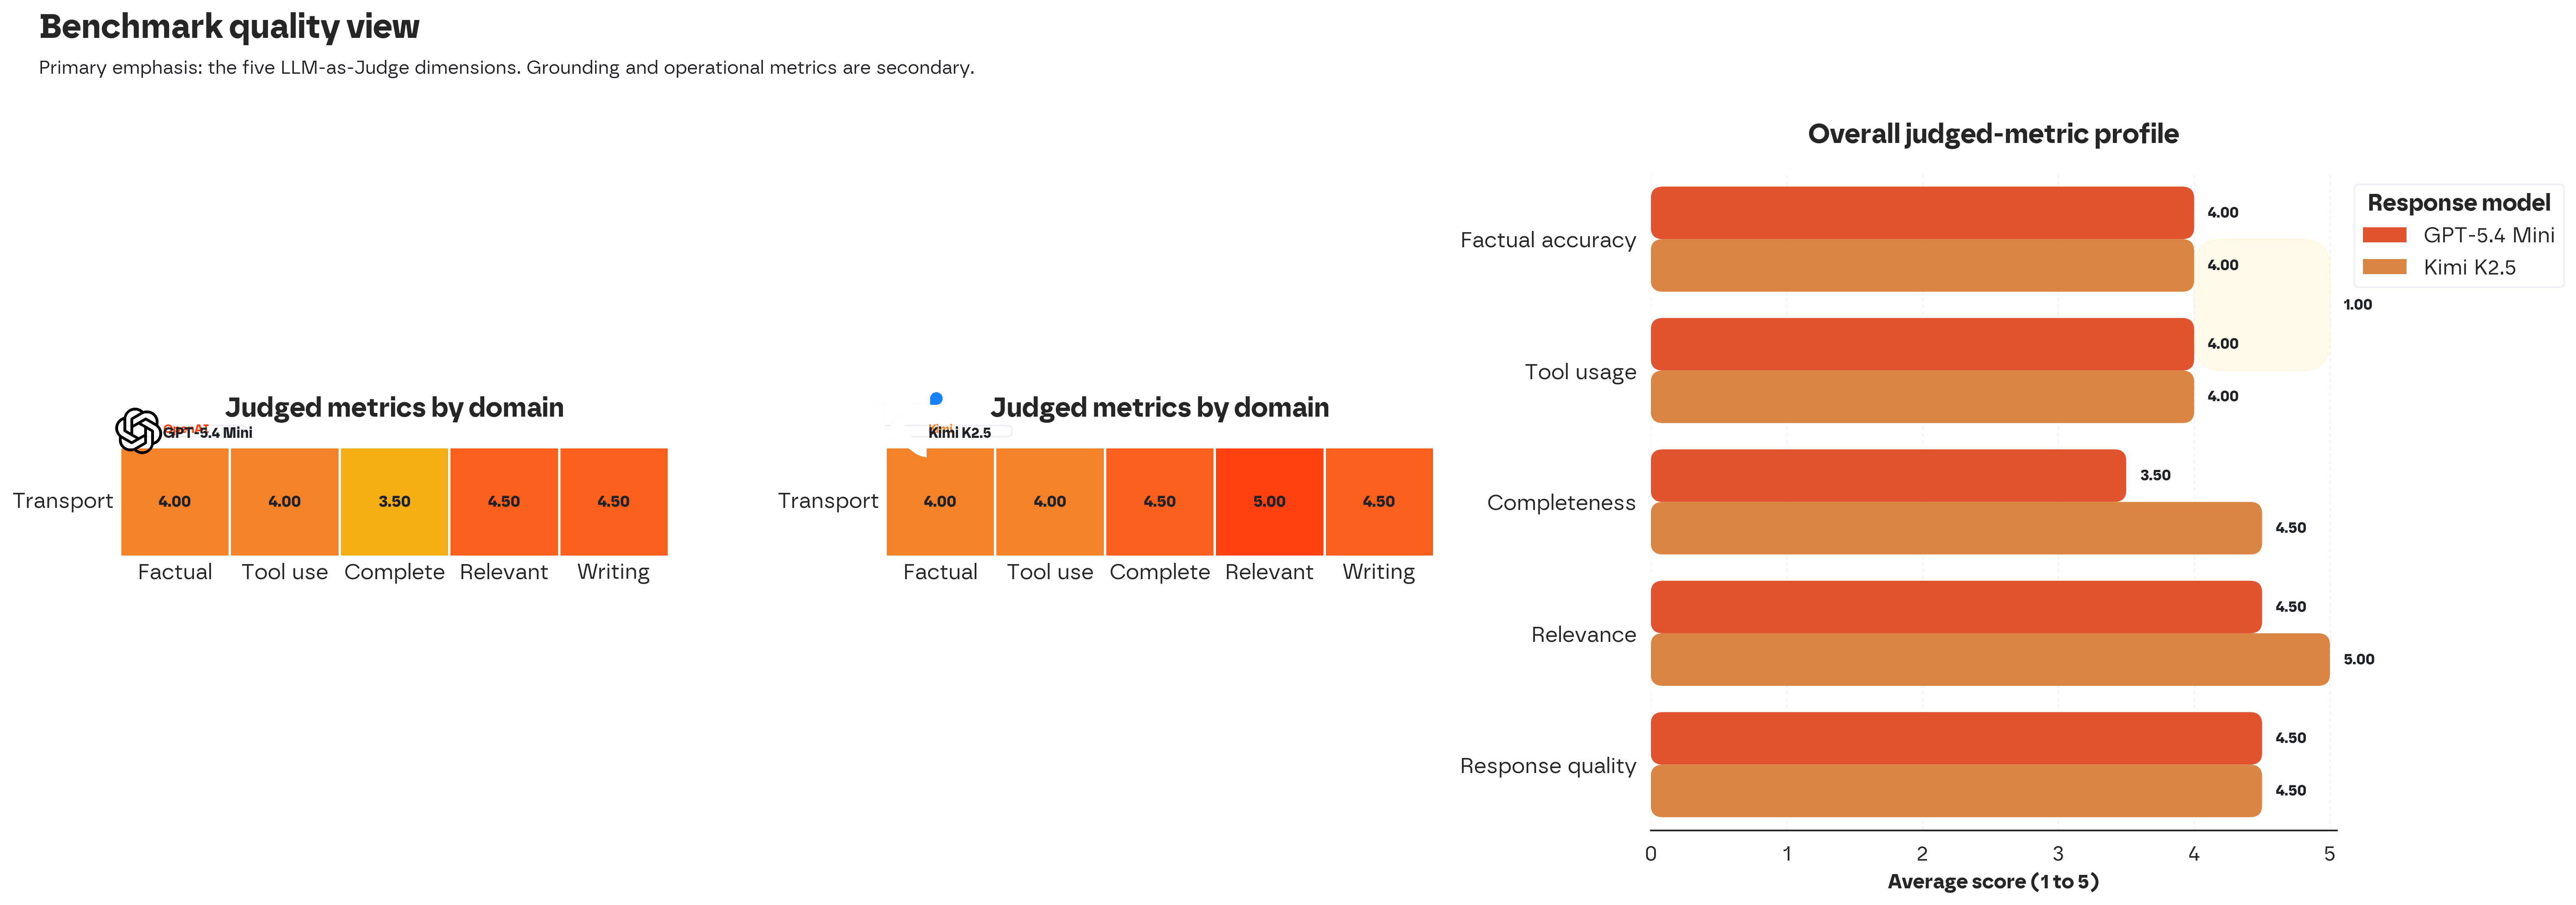

In [26]:
# ==========================================================================
# Benchmark plots: judged metrics first
# ==========================================================================
heatmap_model_order = list(benchmark_model_order)
metric_label_order = [format_metric_label(metric_key) for metric_key in BENCHMARK_METRIC_ORDER]
metric_short_order = [format_metric_label(metric_key, short=True) for metric_key in BENCHMARK_METRIC_ORDER]

fig, axes = plt.subplots(
    1,
    len(heatmap_model_order) + 1,
    figsize=(7.1 * (len(heatmap_model_order) + 1), 7.2),
    dpi=EXPORT_DPI,
    facecolor="white",
    gridspec_kw={"width_ratios": [1.0] * len(heatmap_model_order) + [1.25]},
)
axes = np.atleast_1d(axes)

for axis, model_label in zip(axes[:-1], heatmap_model_order):
    heatmap_frame = (
        benchmark_metric_domain_model_summary[
            benchmark_metric_domain_model_summary["response_model_label"] == model_label
        ]
        .pivot_table(
            index="domain_label",
            columns="metric_short_label",
            values="avg_score",
            aggfunc="first",
            observed=False,
        )
        .reindex(index=benchmark_domain_order)
    )
    available_metric_columns = [label for label in metric_short_order if label in heatmap_frame.columns]
    heatmap_frame = heatmap_frame[available_metric_columns]
    render_metric_heatmap(
        axis,
        heatmap_frame,
        "Judged metrics by domain",
        badge_label=model_label,
        cmap=SCORE_CMAP,
        vmin=1.0,
        vmax=5.0,
    )

overall_axis = axes[-1]
sns.barplot(
    data=benchmark_metric_model_summary,
    y="metric_label",
    x="avg_score",
    hue="response_model_label",
    order=metric_label_order,
    hue_order=heatmap_model_order,
    palette=benchmark_model_palette,
    edgecolor="none",
    ax=overall_axis,
)
style_axis(
    overall_axis,
    "Overall judged-metric profile",
    "Average score (1 to 5)",
    "",
    x_limits=(0, 5.05),
    show_y_grid=False,
)
overall_axis.grid(True, axis="x", linestyle=(0, (3, 2)), alpha=0.7, color=LIGHT_GREY)
overall_axis.axvspan(4.0, 5.0, color=WARM_CREAM, alpha=0.45, zorder=0)
round_bar_patches(overall_axis)
annotate_bar_widths(overall_axis, decimals=2)
style_legend(overall_axis, "Response model", bbox_to_anchor=(1.01, 1.0))

fig.suptitle(
    "Benchmark quality view",
    x=0.02,
    y=1.03,
    ha="left",
    fontsize=20,
    fontweight="bold",
)
fig.text(
    0.02,
    0.96,
    "Primary emphasis: the five LLM-as-Judge dimensions. Grounding and operational metrics are secondary.",
    fontsize=11,
    color=DARK_GREY,
)

plt.tight_layout()
save_figure("benchmark_quality_grounding", fig)
plt.show()

Exported: eval\results\figures\benchmark_operational_profile.svg


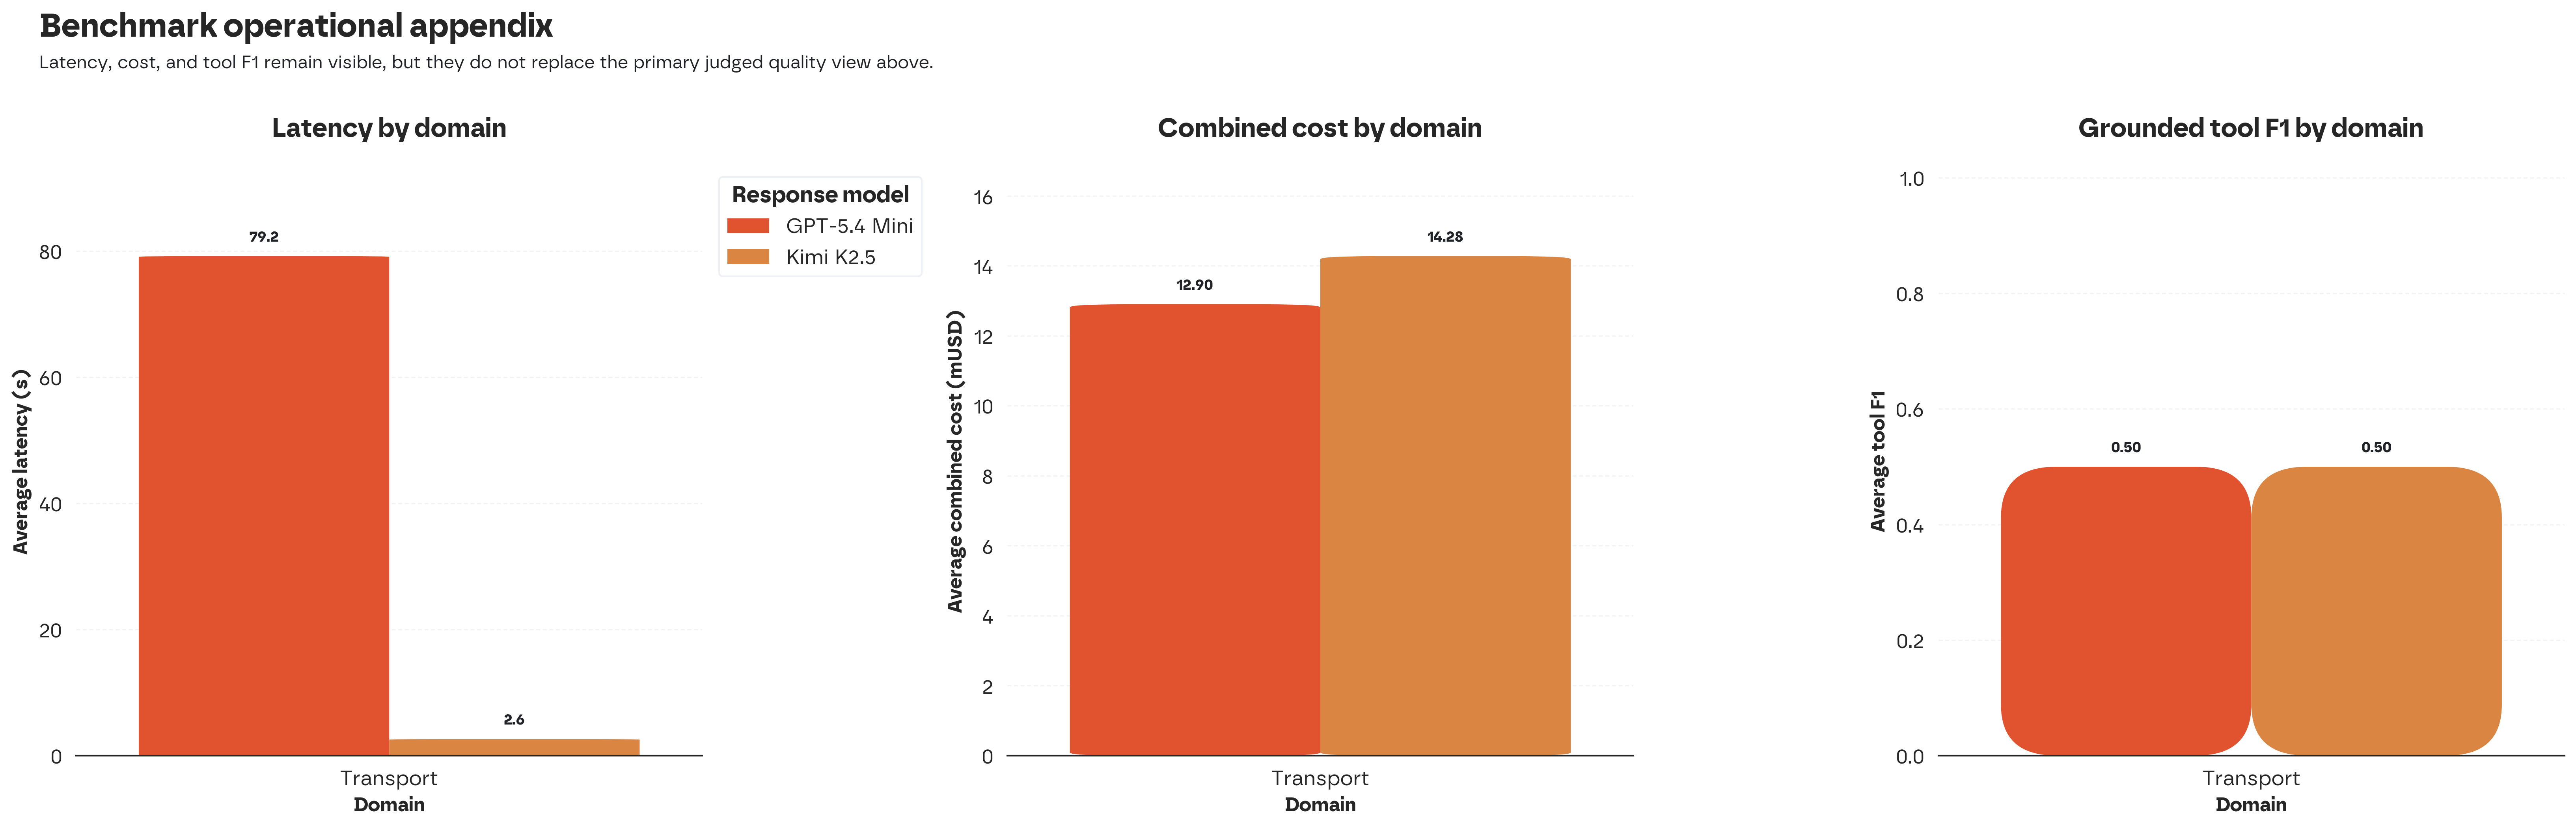

In [17]:
# ==========================================================================
# Benchmark plots: operational appendix
# ==========================================================================
benchmark_operational_by_domain = (
    benchmark_df.groupby(["response_model_label", "domain_label"], as_index=False)
    .agg(
        avg_latency_s=("latency_s", "mean"),
        avg_combined_cost_musd=("combined_total_cost_usd", lambda values: values.mean() * 1000),
        avg_tool_f1=("tool_f1", "mean"),
    )
    .sort_values(["response_model_label", "domain_label"])
)
benchmark_operational_by_domain["response_model_label"] = pd.Categorical(
    benchmark_operational_by_domain["response_model_label"],
    categories=benchmark_model_order,
    ordered=True,
)
benchmark_operational_by_domain["domain_label"] = pd.Categorical(
    benchmark_operational_by_domain["domain_label"],
    categories=benchmark_domain_order,
    ordered=True,
)

fig, axes = plt.subplots(1, 3, figsize=(22, 6.8), dpi=EXPORT_DPI, facecolor="white")
operational_specs = [
    (
        "avg_latency_s",
        "Latency by domain",
        "Average latency (s)",
        max(float(benchmark_operational_by_domain["avg_latency_s"].max() or 0) * 1.18, 1.0),
        1,
    ),
    (
        "avg_combined_cost_musd",
        "Combined cost by domain",
        "Average combined cost (mUSD)",
        max(float(benchmark_operational_by_domain["avg_combined_cost_musd"].max() or 0) * 1.18, 0.05),
        2,
    ),
    (
        "avg_tool_f1",
        "Grounded tool F1 by domain",
        "Average tool F1",
        1.02,
        2,
    ),
]

for index, (metric_name, title, ylabel, upper_bound, decimals) in enumerate(operational_specs):
    axis = axes[index]
    sns.barplot(
        data=benchmark_operational_by_domain,
        x="domain_label",
        y=metric_name,
        hue="response_model_label",
        order=benchmark_domain_order,
        hue_order=benchmark_model_order,
        palette=benchmark_model_palette,
        edgecolor="none",
        ax=axis,
    )
    style_axis(
        axis,
        title,
        "Domain",
        ylabel,
        y_limits=(0, upper_bound),
    )
    round_bar_patches(axis)
    annotate_bar_values(axis, decimals=decimals)
    if index == 0:
        style_legend(axis, "Response model", bbox_to_anchor=(1.01, 1.0))
    elif axis.legend_ is not None:
        axis.legend_.remove()

fig.suptitle(
    "Benchmark operational appendix",
    x=0.02,
    y=1.03,
    ha="left",
    fontsize=20,
    fontweight="bold",
)
fig.text(
    0.02,
    0.96,
    "Latency, cost, and tool F1 remain visible, but they do not replace the primary judged quality view above.",
    fontsize=11,
    color=DARK_GREY,
)

plt.tight_layout()
save_figure("benchmark_operational_profile", fig)
plt.show()

## **Ablation analysis**

The ablation section is shown **by baseline model family**, not as one merged zero-shot bucket. In practice, this means **GPT-5.4 Mini vs LISBOA (GPT profile)** and **Kimi K2.5 vs LISBOA (Kimi profile)** are analysed separately.

The main questions are therefore: **which judged metrics improve**, **where the lift appears by domain**, and **what latency and cost trade-off accompanies that lift for each model family**.

In [18]:
# ==========================================================================
# Ablation tables
# ==========================================================================
if not ablation_available:
    ablation_summary = pd.DataFrame()
    ablation_metric_domain_lift = pd.DataFrame()
    ablation_domain_score_summary = pd.DataFrame()
    lisboa_grounding_table = pd.DataFrame()
    display(Markdown("### Ablation artefact status"))
    print("No ablation JSON found under eval/results/ablation/. Run eval/run_ablation.py to populate this section.")
else:
    ablation_df["profile_name"] = ablation_df["profile_name"].fillna("primary")
    ablation_df["arm_label"] = ablation_df["arm"].apply(format_arm_label)
    ablation_df["domain_label"] = ablation_df["domain"].apply(format_domain_label)
    ablation_df["response_model_label"] = ablation_df["response_model"].apply(format_model_label)
    ablation_df["evaluation_model_label"] = ablation_df["evaluation_model"].apply(format_model_label)

    profile_label_map = (
        ablation_df[ablation_df["arm"] == "zero_shot"]
        .groupby("profile_name")["response_model_label"]
        .first()
        .to_dict()
    )
    ablation_df["profile_label"] = ablation_df["profile_name"].map(profile_label_map)
    ablation_df["profile_label"] = ablation_df["profile_label"].fillna(ablation_df["response_model_label"])

    ablation_profile_order = sorted(
        ablation_df["profile_label"].dropna().unique(),
        key=model_sort_key,
    )
    ablation_domain_order = [
        label for label in ABLATION_DOMAIN_ORDER if label in ablation_df["domain_label"].dropna().unique()
    ]
    ablation_arm_order = ["Zero-shot", "LISBOA"]

    ablation_metric_long = build_metric_long_frame(
        ablation_df,
        [
            "id",
            "query",
            "profile_name",
            "profile_label",
            "arm",
            "arm_label",
            "domain",
            "domain_label",
            "response_model",
            "response_model_label",
            "latency_s",
            "combined_total_tokens",
            "combined_total_cost_usd",
            "tool_f1",
            "heuristics_pass",
        ],
    )

    ablation_summary = (
        ablation_df.groupby(["profile_label", "arm_label", "domain_label"], as_index=False)
        .agg(
            queries=("id", "nunique"),
            avg_composite_score=("composite_score", "mean"),
            avg_latency_s=("latency_s", "mean"),
            avg_combined_tokens=("combined_total_tokens", "mean"),
            avg_combined_cost_musd=("combined_total_cost_usd", lambda values: values.mean() * 1000),
            avg_tool_f1=("tool_f1", "mean"),
            heuristics_pass_rate=("heuristics_pass", "mean"),
        )
    )
    ablation_summary["profile_label"] = pd.Categorical(
        ablation_summary["profile_label"],
        categories=ablation_profile_order,
        ordered=True,
    )
    ablation_summary["arm_label"] = pd.Categorical(
        ablation_summary["arm_label"],
        categories=ablation_arm_order,
        ordered=True,
    )
    ablation_summary["domain_label"] = pd.Categorical(
        ablation_summary["domain_label"],
        categories=ablation_domain_order,
        ordered=True,
    )
    ablation_summary = ablation_summary.sort_values(["profile_label", "arm_label", "domain_label"])

    ablation_metric_profile_summary = (
        ablation_metric_long.groupby(["profile_label", "arm_label", "metric_key"], as_index=False, observed=False)
        .agg(avg_score=("metric_score", "mean"))
    )
    ablation_metric_profile_summary["metric_label"] = ablation_metric_profile_summary["metric_key"].apply(format_metric_label)
    ablation_metric_profile_summary["profile_label"] = pd.Categorical(
        ablation_metric_profile_summary["profile_label"],
        categories=ablation_profile_order,
        ordered=True,
    )
    ablation_metric_profile_summary["arm_label"] = pd.Categorical(
        ablation_metric_profile_summary["arm_label"],
        categories=ablation_arm_order,
        ordered=True,
    )
    ablation_metric_profile_summary["metric_label"] = pd.Categorical(
        ablation_metric_profile_summary["metric_label"],
        categories=[format_metric_label(metric_key) for metric_key in BENCHMARK_METRIC_ORDER],
        ordered=True,
    )
    ablation_metric_profile_summary = ablation_metric_profile_summary.sort_values(
        ["profile_label", "arm_label", "metric_label"]
    )

    ablation_metric_profile_lift = (
        ablation_metric_profile_summary.pivot_table(
            index=["profile_label", "metric_label"],
            columns="arm_label",
            values="avg_score",
            aggfunc="first",
            observed=False,
        )
        .reset_index()
    )
    ablation_metric_profile_lift.columns.name = None
    ablation_metric_profile_lift["metric_lift"] = (
        ablation_metric_profile_lift.get("LISBOA", np.nan)
        - ablation_metric_profile_lift.get("Zero-shot", np.nan)
    )

    ablation_metric_domain_summary = (
        ablation_metric_long.groupby(
            ["profile_label", "domain_label", "arm_label", "metric_key"],
            as_index=False,
            observed=False,
        )
        .agg(avg_score=("metric_score", "mean"))
    )
    ablation_metric_domain_summary["metric_label"] = ablation_metric_domain_summary["metric_key"].apply(format_metric_label)
    ablation_metric_domain_summary["metric_short_label"] = ablation_metric_domain_summary["metric_key"].apply(
        lambda value: format_metric_label(value, short=True)
    )
    ablation_metric_domain_lift = (
        ablation_metric_domain_summary.pivot_table(
            index=["profile_label", "domain_label", "metric_label", "metric_short_label"],
            columns="arm_label",
            values="avg_score",
            aggfunc="first",
            observed=False,
        )
        .reset_index()
    )
    ablation_metric_domain_lift.columns.name = None
    ablation_metric_domain_lift["metric_lift"] = (
        ablation_metric_domain_lift.get("LISBOA", np.nan)
        - ablation_metric_domain_lift.get("Zero-shot", np.nan)
    )

    ablation_domain_score_summary = (
        ablation_summary[[
            "profile_label",
            "arm_label",
            "domain_label",
            "queries",
            "avg_composite_score",
            "avg_latency_s",
            "avg_combined_tokens",
            "avg_combined_cost_musd",
            "avg_tool_f1",
            "heuristics_pass_rate",
        ]]
        .copy()
    )

    score_table = (
        ablation_domain_score_summary.pivot_table(
            index=["profile_label", "domain_label"],
            columns="arm_label",
            values="avg_composite_score",
            aggfunc="first",
            observed=False,
        )
        .reset_index()
    )
    score_table.columns.name = None
    score_table["Score lift"] = score_table.get("LISBOA", np.nan) - score_table.get("Zero-shot", np.nan)
    score_table = score_table.rename(
        columns={
            "profile_label": "Profile",
            "domain_label": "Domain",
            "Zero-shot": "Zero-shot score",
            "LISBOA": "LISBOA score",
        }
    )

    latency_table = (
        ablation_domain_score_summary.pivot_table(
            index=["profile_label", "domain_label"],
            columns="arm_label",
            values="avg_latency_s",
            aggfunc="first",
            observed=False,
        )
        .reset_index()
        .rename(
            columns={
                "profile_label": "Profile",
                "domain_label": "Domain",
                "Zero-shot": "Zero-shot latency (s)",
                "LISBOA": "LISBOA latency (s)",
            }
        )
    )
    latency_table.columns.name = None

    cost_table = (
        ablation_domain_score_summary.pivot_table(
            index=["profile_label", "domain_label"],
            columns="arm_label",
            values="avg_combined_cost_musd",
            aggfunc="first",
            observed=False,
        )
        .reset_index()
        .rename(
            columns={
                "profile_label": "Profile",
                "domain_label": "Domain",
                "Zero-shot": "Zero-shot cost (mUSD)",
                "LISBOA": "LISBOA cost (mUSD)",
            }
        )
    )
    cost_table.columns.name = None

    ablation_tradeoff_table = score_table.merge(latency_table, on=["Profile", "Domain"], how="left").merge(
        cost_table,
        on=["Profile", "Domain"],
        how="left",
    )

    ablation_metric_lift_table = (
        ablation_metric_profile_lift.pivot_table(
            index="profile_label",
            columns="metric_label",
            values="metric_lift",
            aggfunc="first",
            observed=False,
        )
        .reindex(index=ablation_profile_order)
        .reset_index()
        .rename(columns={"profile_label": "Profile"})
    )
    ablation_metric_lift_table.columns.name = None

    lisboa_grounding_table = (
        ablation_df[ablation_df["arm_label"] == "LISBOA"]
        .groupby(["profile_label", "domain_label"], as_index=False)
        .agg(
            avg_tool_precision=("tool_precision", "mean"),
            avg_tool_recall=("tool_recall", "mean"),
            avg_tool_f1=("tool_f1", "mean"),
        )
        .rename(
            columns={
                "profile_label": "Profile",
                "domain_label": "Domain",
                "avg_tool_precision": "LISBOA tool precision",
                "avg_tool_recall": "LISBOA tool recall",
                "avg_tool_f1": "LISBOA tool F1",
            }
        )
    )

    metric_columns = [format_metric_label(metric_key) for metric_key in BENCHMARK_METRIC_ORDER]

    display(Markdown("### Ablation metric lift by baseline model"))
    display_styled_table(
        ablation_metric_lift_table,
        caption="Positive values mean LISBOA outscored the corresponding zero-shot baseline on that judged metric.",
        gradient_subset=metric_columns,
        cmap=LIFT_CMAP,
        precision=2,
        vmin=-1.0,
        vmax=1.0,
    )

    display(Markdown("### Ablation composite score by profile and domain"))
    display_styled_table(
        score_table,
        caption="Composite-score comparison is kept separate for GPT-5.4 Mini and Kimi K2.5.",
        gradient_subset=["Zero-shot score", "LISBOA score", "Score lift"],
        cmap=SCORE_CMAP,
        precision=2,
    )

    display(Markdown("### Ablation trade-off table"))
    display_styled_table(
        ablation_tradeoff_table,
        caption="Compact operational comparison for the same profile and domain pairs used in the quality plots.",
        gradient_subset=[
            "Zero-shot score",
            "LISBOA score",
            "Score lift",
            "Zero-shot latency (s)",
            "LISBOA latency (s)",
            "Zero-shot cost (mUSD)",
            "LISBOA cost (mUSD)",
        ],
        cmap=SCORE_CMAP,
        precision=2,
    )

    display(Markdown("### LISBOA-only grounded tool appendix"))
    display_styled_table(
        lisboa_grounding_table,
        caption="Grounded tool metrics remain supporting evidence and are shown only for the LISBOA arm.",
        gradient_subset=["LISBOA tool precision", "LISBOA tool recall", "LISBOA tool F1"],
        cmap=SCORE_CMAP,
        precision=2,
    )

### Ablation metric lift by baseline model

Profile,Factual accuracy,Tool usage,Completeness,Relevance,Response quality
GPT-5.4 Mini,0.25,2.50,0.00,-0.50,-0.25
Kimi K2.5,0.75,1.50,0.75,0.25,-0.25


### Ablation composite score by profile and domain

Profile,Domain,Zero-shot score,LISBOA score,Score lift
GPT-5.4 Mini,Transport,3.50,3.30,-0.20
GPT-5.4 Mini,Multi-agent,2.60,3.60,1.00
Kimi K2.5,Transport,3.00,3.90,0.90
Kimi K2.5,Multi-agent,2.70,3.00,0.30


### Ablation trade-off table

Profile,Domain,Zero-shot score,LISBOA score,Score lift,Zero-shot latency (s),LISBOA latency (s),Zero-shot cost (mUSD),LISBOA cost (mUSD)
GPT-5.4 Mini,Transport,3.50,3.30,-0.20,1.58,15.10,15.30,27.92
GPT-5.4 Mini,Multi-agent,2.60,3.60,1.00,5.50,46.18,14.55,101.26
Kimi K2.5,Transport,3.00,3.90,0.90,7.55,41.50,21.11,36.99
Kimi K2.5,Multi-agent,2.70,3.00,0.30,16.13,114.78,22.35,85.68


### LISBOA-only grounded tool appendix

Profile,Domain,LISBOA tool precision,LISBOA tool recall,LISBOA tool F1
GPT-5.4 Mini,Multi-agent,0.27,0.75,0.40
GPT-5.4 Mini,Transport,0.33,1.00,0.50
Kimi K2.5,Multi-agent,0.33,0.50,0.40
Kimi K2.5,Transport,0.33,1.00,0.50


Exported: eval\results\figures\ablation_quality_lift.svg


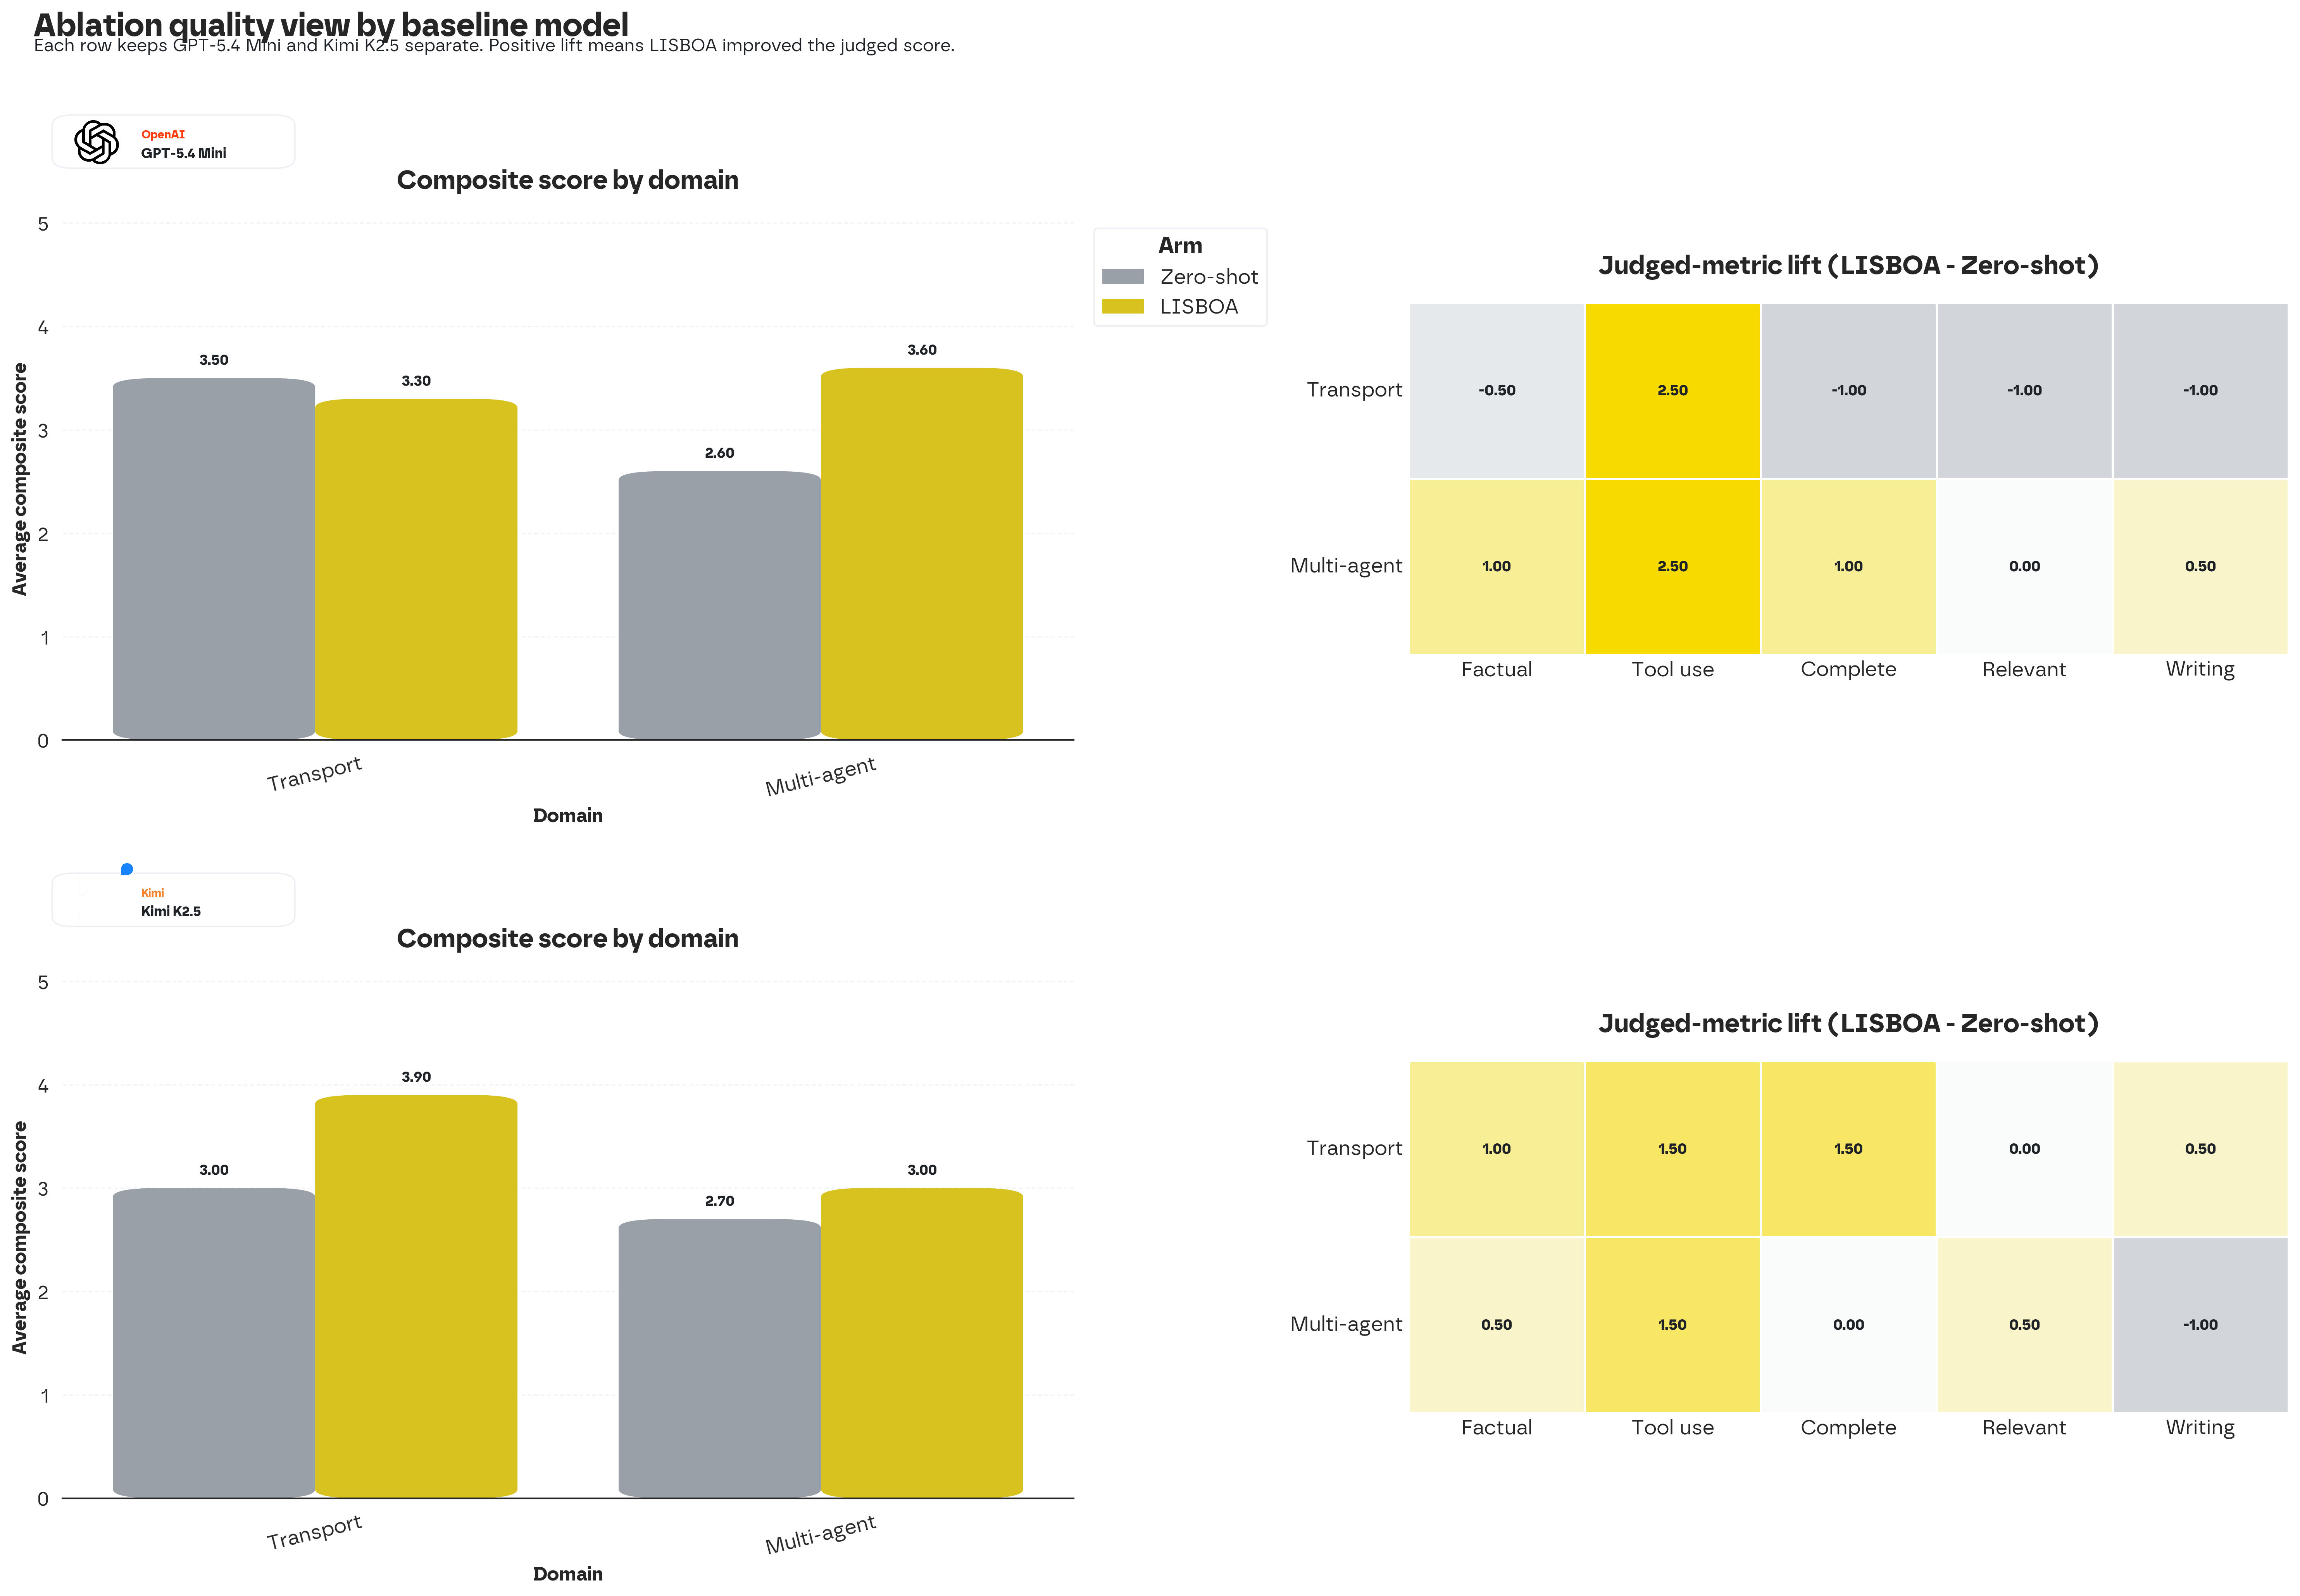

In [27]:
# ==========================================================================
# Ablation plots: quality comparison by baseline model
# ==========================================================================
if ablation_summary.empty or ablation_metric_domain_lift.empty:
    print("Skipping ablation quality plots because no ablation artefact is available.")
else:
    profile_count = len(ablation_profile_order)
    fig, axes = plt.subplots(
        profile_count,
        2,
        figsize=(20, 6.8 * profile_count),
        dpi=EXPORT_DPI,
        facecolor="white",
        gridspec_kw={"width_ratios": [1.15, 1.0]},
    )
    axes = np.atleast_2d(axes)

    lift_limit = max(float(ablation_metric_domain_lift["metric_lift"].abs().max() or 0), 0.25)
    metric_short_order = [format_metric_label(metric_key, short=True) for metric_key in BENCHMARK_METRIC_ORDER]

    for row_index, profile_label in enumerate(ablation_profile_order):
        score_axis = axes[row_index, 0]
        lift_axis = axes[row_index, 1]

        profile_score_frame = ablation_domain_score_summary[
            ablation_domain_score_summary["profile_label"] == profile_label
        ].copy()
        profile_domain_order = [
            label
            for label in ablation_domain_order
            if label in profile_score_frame["domain_label"].dropna().unique()
        ]

        sns.barplot(
            data=profile_score_frame,
            x="domain_label",
            y="avg_composite_score",
            hue="arm_label",
            order=profile_domain_order,
            hue_order=ablation_arm_order,
            palette=ARM_PALETTE,
            edgecolor="none",
            ax=score_axis,
        )
        style_axis(
            score_axis,
            "Composite score by domain",
            "Domain",
            "Average composite score",
            rotate_xticks=14,
            y_limits=(0, 5.05),
        )
        round_bar_patches(score_axis)
        annotate_bar_values(score_axis, decimals=2)
        add_brand_badge(score_axis, profile_label)
        if row_index == 0:
            style_legend(score_axis, "Arm", bbox_to_anchor=(1.01, 1.0))
        elif score_axis.legend_ is not None:
            score_axis.legend_.remove()

        lift_frame = (
            ablation_metric_domain_lift[
                ablation_metric_domain_lift["profile_label"] == profile_label
            ]
            .pivot_table(
                index="domain_label",
                columns="metric_short_label",
                values="metric_lift",
                aggfunc="first",
                observed=False,
            )
            .reindex(index=profile_domain_order)
        )
        available_columns = [label for label in metric_short_order if label in lift_frame.columns]
        lift_frame = lift_frame[available_columns]
        render_metric_heatmap(
            lift_axis,
            lift_frame,
            "Judged-metric lift (LISBOA - Zero-shot)",
            cmap=LIFT_CMAP,
            vmin=-lift_limit,
            vmax=lift_limit,
            center=0.0,
        )

    fig.suptitle(
        "Ablation quality view by baseline model",
        x=0.02,
        y=1.01,
        ha="left",
        fontsize=20,
        fontweight="bold",
    )
    fig.text(
        0.02,
        0.985,
        "Each row keeps GPT-5.4 Mini and Kimi K2.5 separate. Positive lift means LISBOA improved the judged score.",
        fontsize=11,
        color=DARK_GREY,
    )

    plt.tight_layout()
    save_figure("ablation_quality_lift", fig)
    plt.show()

Exported: eval\results\figures\ablation_tradeoffs.svg


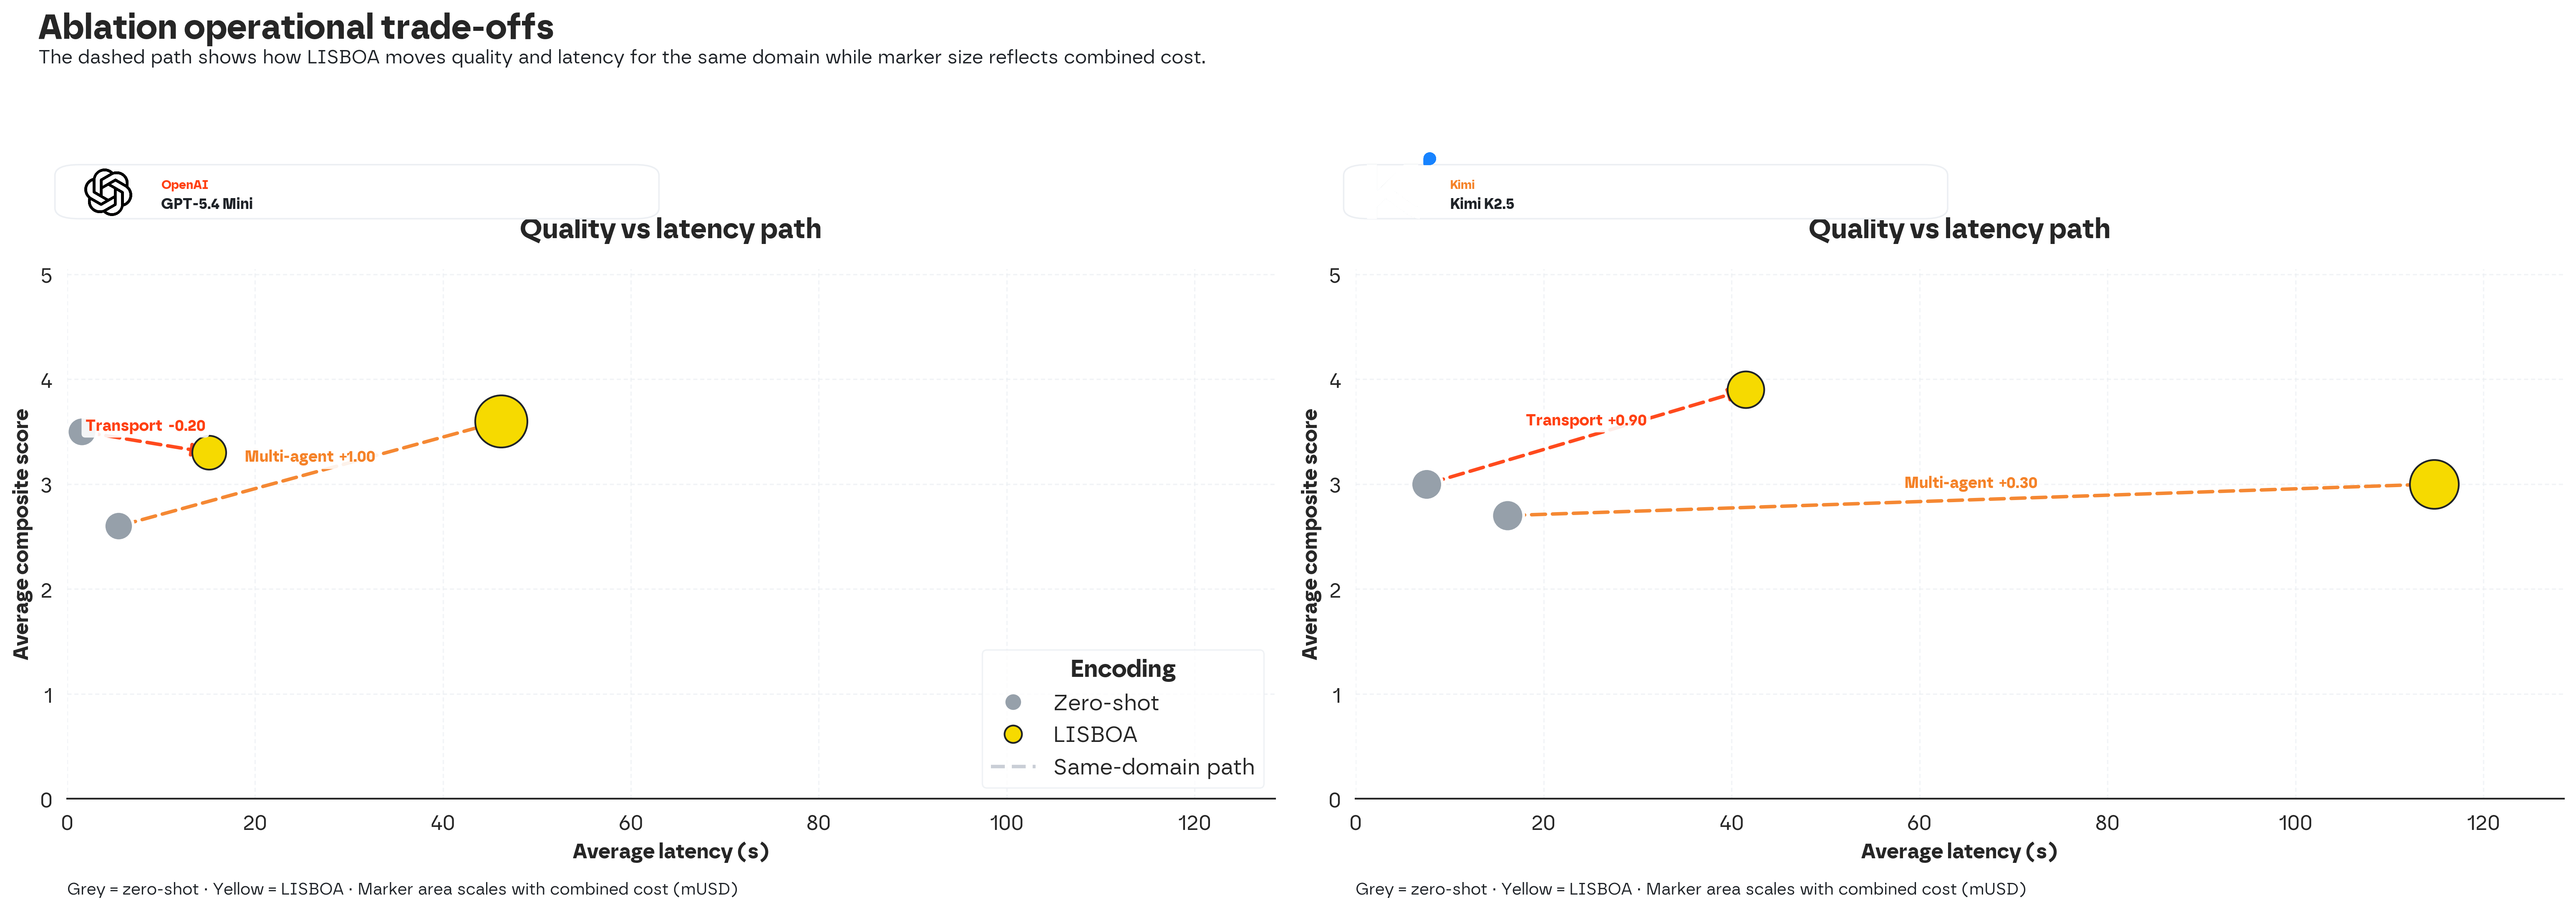

In [28]:
# ==========================================================================
# Ablation plots: operational trade-offs by baseline model
# ==========================================================================
if ablation_summary.empty:
    print("Skipping ablation trade-off plots because no ablation artefact is available.")
else:
    profile_count = len(ablation_profile_order)
    fig, axes = plt.subplots(
        1,
        profile_count,
        figsize=(10.4 * profile_count, 7.4),
        dpi=EXPORT_DPI,
        facecolor="white",
    )
    axes = np.atleast_1d(axes)

    all_domains = [
        label for label in ablation_domain_order if label in ablation_domain_score_summary["domain_label"].dropna().unique()
    ]
    domain_palette = {
        domain_label: PROJECT_PALETTE[index % len(PROJECT_PALETTE)]
        for index, domain_label in enumerate(all_domains)
    }
    max_cost_musd = max(float(ablation_domain_score_summary["avg_combined_cost_musd"].max() or 0), 0.01)
    max_latency = max(float(ablation_domain_score_summary["avg_latency_s"].max() or 0), 1.0)

    for axis, profile_label in zip(axes, ablation_profile_order):
        profile_frame = ablation_domain_score_summary[
            ablation_domain_score_summary["profile_label"] == profile_label
        ].copy()
        profile_domain_order = [
            label for label in ablation_domain_order if label in profile_frame["domain_label"].dropna().unique()
        ]

        for domain_label in profile_domain_order:
            pair = profile_frame[profile_frame["domain_label"] == domain_label]
            if pair["arm_label"].nunique() < 2:
                continue

            zero_shot_row = pair[pair["arm_label"] == "Zero-shot"].iloc[0]
            lisboa_row = pair[pair["arm_label"] == "LISBOA"].iloc[0]
            domain_color = domain_palette[domain_label]

            path = FancyArrowPatch(
                (float(zero_shot_row["avg_latency_s"]), float(zero_shot_row["avg_composite_score"])),
                (float(lisboa_row["avg_latency_s"]), float(lisboa_row["avg_composite_score"])),
                arrowstyle="-|>",
                mutation_scale=15,
                linewidth=2.0,
                linestyle=(0, (4, 2)),
                color=domain_color,
                alpha=0.95,
                zorder=3,
            )
            axis.add_patch(path)

            zero_shot_size = 180 + 720 * (float(zero_shot_row["avg_combined_cost_musd"] or 0) / max_cost_musd)
            lisboa_size = 180 + 720 * (float(lisboa_row["avg_combined_cost_musd"] or 0) / max_cost_musd)
            axis.scatter(
                float(zero_shot_row["avg_latency_s"]),
                float(zero_shot_row["avg_composite_score"]),
                s=zero_shot_size,
                color=NEUTRAL_GREY,
                edgecolor="white",
                linewidth=1.6,
                zorder=4,
            )
            axis.scatter(
                float(lisboa_row["avg_latency_s"]),
                float(lisboa_row["avg_composite_score"]),
                s=lisboa_size,
                color=ACCENT_YELLOW,
                edgecolor=DARK_GREY,
                linewidth=1.0,
                zorder=5,
            )

            midpoint_x = (float(zero_shot_row["avg_latency_s"]) + float(lisboa_row["avg_latency_s"])) / 2.0
            midpoint_y = (float(zero_shot_row["avg_composite_score"]) + float(lisboa_row["avg_composite_score"])) / 2.0
            score_lift = float(lisboa_row["avg_composite_score"] or 0) - float(zero_shot_row["avg_composite_score"] or 0)
            axis.text(
                midpoint_x,
                midpoint_y + 0.08,
                f"{domain_label}  {score_lift:+.2f}",
                ha="center",
                va="bottom",
                fontsize=9.2,
                fontweight="bold",
                color=domain_color,
                bbox={"boxstyle": "round,pad=0.24", "facecolor": "white", "edgecolor": "none", "alpha": 0.9},
                zorder=6,
            )

        style_axis(
            axis,
            "Quality vs latency path",
            "Average latency (s)",
            "Average composite score",
            x_limits=(0, max_latency * 1.12),
            y_limits=(0, 5.05),
            show_y_grid=True,
        )
        axis.grid(True, axis="x", linestyle=(0, (3, 2)), alpha=0.65, color=LIGHT_GREY)
        add_brand_badge(axis, profile_label, width=0.48)
        axis.text(
            0.0,
            -0.18,
            "Grey = zero-shot · Yellow = LISBOA · Marker area scales with combined cost (mUSD)",
            transform=axis.transAxes,
            fontsize=9.5,
            color=DARK_GREY,
            ha="left",
        )

    legend_handles = [
        Line2D([0], [0], marker="o", color="none", markerfacecolor=NEUTRAL_GREY, markeredgecolor="white", markersize=10, label="Zero-shot"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor=ACCENT_YELLOW, markeredgecolor=DARK_GREY, markersize=10, label="LISBOA"),
        Line2D([0], [0], color=MID_GREY, linestyle=(0, (4, 2)), linewidth=2.0, label="Same-domain path"),
    ]
    axes[0].legend(handles=legend_handles, loc="lower right", frameon=True, title="Encoding")
    axes[0].legend_.get_title().set_fontweight("bold")
    axes[0].legend_.get_frame().set_edgecolor(LIGHT_GREY)
    axes[0].legend_.get_frame().set_facecolor("white")

    fig.suptitle(
        "Ablation operational trade-offs",
        x=0.02,
        y=1.02,
        ha="left",
        fontsize=20,
        fontweight="bold",
    )
    fig.text(
        0.02,
        0.965,
        "The dashed path shows how LISBOA moves quality and latency for the same domain while marker size reflects combined cost.",
        fontsize=11,
        color=DARK_GREY,
    )

    plt.tight_layout()
    save_figure("ablation_tradeoffs", fig)
    plt.show()

In [30]:
# ==========================================================================
# Coverage, provider consistency, and optional calibration
# ==========================================================================
display(Markdown("## Coverage and provider consistency"))

if coverage_payload is not None:
    coverage_overview = pd.DataFrame(
        [
            {
                "Artefact": str(coverage_path.relative_to(PROJECT_ROOT)),
                "Prompts": coverage_summary_payload.get("total_prompts", len(coverage_df)),
                "Successful prompts": coverage_summary_payload.get("successful_prompts", np.nan),
                "Average tool F1": coverage_summary_payload.get("avg_tool_f1", np.nan),
                "Full registry covered": coverage_summary_payload.get("full_registry_coverage_met", False),
                "Missing tools": len(coverage_summary_payload.get("missing_tools", [])),
            }
        ]
    )
    display(Markdown("### Strict live coverage snapshot"))
    display(coverage_overview.round(6))

    if not coverage_df.empty:
        coverage_df["domain_label"] = coverage_df["domain"].apply(format_domain_label)
        coverage_domain_summary = (
            coverage_df.groupby("domain_label", as_index=False)
            .agg(
                prompts=("id", "count"),
                pass_rate=("coverage_pass", "mean"),
                avg_tool_f1=("tool_metrics", lambda values: np.mean([(value or {}).get("tool_f1", np.nan) for value in values])),
                avg_latency_s=("latency_s", "mean"),
            )
            .rename(
                columns={
                    "domain_label": "Domain",
                    "prompts": "Prompts",
                    "pass_rate": "Coverage pass rate",
                    "avg_tool_f1": "Avg tool F1",
                    "avg_latency_s": "Avg latency (s)",
                }
            )
        )
        display(Markdown("### Coverage by domain"))
        display(coverage_domain_summary.round(6))
else:
    print("No coverage JSON found. Run the strict live coverage suite when you need this section.")

if consistency_payload is not None:
    consistency_overview = pd.DataFrame(
        [
            {
                "Artefact": str(consistency_path.relative_to(PROJECT_ROOT)),
                "Providers compared": ", ".join(consistency_payload.get("providers", [])),
                "Prompts": consistency_summary_payload.get("total_prompts", np.nan),
                "Completed comparisons": consistency_summary_payload.get("completed_comparisons", np.nan),
                "Consistency rate": consistency_summary_payload.get("consistency_rate", np.nan),
            }
        ]
    )
    display(Markdown("### Provider consistency snapshot"))
    display(consistency_overview.round(6))

    per_provider = consistency_summary_payload.get("per_provider", {}) or {}
    if per_provider:
        consistency_provider_summary = (
            pd.DataFrame.from_dict(per_provider, orient="index")
            .reset_index()
            .rename(
                columns={
                    "index": "Provider",
                    "count": "Comparisons",
                    "avg_latency_s": "Avg latency (s)",
                    "overall_pass_rate": "Heuristics pass rate",
                }
            )
        )
        display(Markdown("### Provider-level comparison"))
        display(consistency_provider_summary.round(6))

    if not consistency_df.empty:
        consistency_df["category_label"] = consistency_df["category"].apply(format_domain_label)
        consistency_view = consistency_df.rename(
            columns={
                "id": "Query ID",
                "category_label": "Category",
                "provider": "Provider",
                "model_name": "Model",
                "latency_s": "Latency (s)",
                "overall_pass": "Heuristics pass",
                "consistent": "Consistent",
            }
        )
        display(Markdown("### Query-level provider consistency view"))
        display(consistency_view[["Query ID", "Category", "Provider", "Model", "Latency (s)", "Heuristics pass", "Consistent"]].round(6))
else:
    print("No provider consistency JSON found. Add this section only after running the consistency script.")

if calibration_payload is not None:
    calibration_summary = pd.json_normalize(calibration_payload.get("summary", {}).get("per_dimension", {}), sep=".")
    display(Markdown("### Optional calibration snapshot"))
    display(calibration_summary.T)
else:
    print("No calibration JSON found. Human-vs-judge calibration remains optional until scores are available.")

## Coverage and provider consistency

No coverage JSON found. Run the strict live coverage suite when you need this section.
No provider consistency JSON found. Add this section only after running the consistency script.
No calibration JSON found. Human-vs-judge calibration remains optional until scores are available.


In [31]:
# ==========================================================================
# Optional flat-table export policy
# ==========================================================================
if EXPORT_FLAT_TABLES:
    benchmark_flat_path = EVAL_RESULTS_DIR / "benchmark" / "benchmark_flat_latest.csv"
    benchmark_summary_path = EVAL_RESULTS_DIR / "benchmark" / "benchmark_summary_latest.csv"
    ablation_flat_path = EVAL_RESULTS_DIR / "ablation" / "ablation_flat_latest.csv"
    ablation_summary_path = EVAL_RESULTS_DIR / "ablation" / "ablation_summary_latest.csv"

    benchmark_df.to_csv(benchmark_flat_path, index=False)
    benchmark_summary.to_csv(benchmark_summary_path, index=False)
    ablation_df.to_csv(ablation_flat_path, index=False)
    ablation_summary.to_csv(ablation_summary_path, index=False)

    print("Exported flat tables:")
    print(f" - {benchmark_flat_path.relative_to(PROJECT_ROOT)}")
    print(f" - {benchmark_summary_path.relative_to(PROJECT_ROOT)}")
    print(f" - {ablation_flat_path.relative_to(PROJECT_ROOT)}")
    print(f" - {ablation_summary_path.relative_to(PROJECT_ROOT)}")
else:
    print("Flat CSV export is disabled by default in this notebook.")
    print("Set EXPORT_FLAT_TABLES = True in the setup cell if you need appendix-ready CSV snapshots.")

print("Main figure export policy:")
print(f" - Automatic figure export enabled: {EXPORT_MAIN_FIGURES}")
print(f" - Exported figure names: {', '.join(sorted(MAIN_FIGURE_EXPORTS))}")

Flat CSV export is disabled by default in this notebook.
Set EXPORT_FLAT_TABLES = True in the setup cell if you need appendix-ready CSV snapshots.
Main figure export policy:
 - Automatic figure export enabled: True
 - Exported figure names: ablation_quality_lift, ablation_tradeoffs, benchmark_operational_profile, benchmark_quality_grounding


## **Notes for thesis writing**

- This notebook separates the **shared corpus definition** from the smaller persisted subsets used by benchmark, ablation, coverage, and provider-consistency artefacts.
- The main benchmark figures compare isolated worker-agent behaviour, not the full LISBOA orchestration pipeline.
- The ablation figures focus on **quality lift** and **operational trade-offs**, not on a symmetric tool-use comparison between zero-shot and LISBOA.
- Coverage and provider consistency are summarised compactly because they support the evaluation narrative but should not dominate the main thesis figures.
- Automatic export is restricted to the main SVG figures only. Flat CSV snapshots remain optional and can be enabled explicitly when needed for appendix work.
- Model labels shown in the notebook are cleaned for readability, but the underlying metadata is always read from the saved JSON artefacts.
- The demo corpus should be run with custom output prefixes such as `ablation_demo` or `benchmark_demo`, so it is persisted for presentation purposes without replacing the main latest artefacts used by this notebook.